# Baseline Model Operation - 三因子 EM + 拟牛顿法版


## 0. 读取变量准备产物


In [209]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

plt.rcParams["axes.unicode_minus"] = False
for font_name in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Arial Unicode MS"]:
    current_fonts = plt.rcParams.get("font.sans-serif", [])
    if font_name not in current_fonts:
        plt.rcParams["font.sans-serif"] = [font_name] + current_fonts

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "AGENTS.md").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "AGENTS.md").exists():
            PROJECT_ROOT = parent
            break

MONTHLY_MODEL_DIR = "月频模型"
INTERMEDIATE_DIR_NAME = "模型流程中产物"
OUTPUT_DIR = PROJECT_ROOT / MONTHLY_MODEL_DIR / "processed"
INTERMEDIATE_DIR = PROJECT_ROOT / MONTHLY_MODEL_DIR / INTERMEDIATE_DIR_NAME

TRAIN_START = pd.Period("2005-01", freq="M")
TRAIN_END = pd.Period("2014-12", freq="M")
TRAIN_WINDOW_TAG = f"{TRAIN_START.year:04d}{TRAIN_START.month:02d}_{TRAIN_END.year:04d}{TRAIN_END.month:02d}"
PREP_META_PATH = OUTPUT_DIR / f"baseline_variable_preparation_meta_{TRAIN_WINDOW_TAG}.json"
if not PREP_META_PATH.exists():
    raise FileNotFoundError(f"Run the variable preparation notebook first; missing metadata: {PREP_META_PATH}")

prep_meta = json.loads(PREP_META_PATH.read_text(encoding="utf-8"))
TIME_COL = prep_meta["time_col"]
GDP_COL = prep_meta["gdp_col"]
MODEL_COLS_CANDIDATE = prep_meta["model_cols"]
PCA_INIT_COLS = prep_meta.get("pca_init_cols", [col for col in MODEL_COLS_CANDIDATE if col != prep_meta["gdp_col"]])
THREE_FACTOR_EXTRA_COLS = [col for col in ["服务业PMI"] if col in MODEL_COLS_CANDIDATE]
MODEL_COLS = [prep_meta["gdp_col"]] + [
    col for col in PCA_INIT_COLS + THREE_FACTOR_EXTRA_COLS
    if col != prep_meta["gdp_col"]
]
MODEL_COLS = list(dict.fromkeys(MODEL_COLS))
BASE_MODEL_COLS = prep_meta.get("base_model_cols", MODEL_COLS_CANDIDATE)
TRAIN_START = pd.Period(prep_meta["train_start"], freq="M")
TRAIN_END = pd.Period(prep_meta["train_end"], freq="M")
TRAIN_WINDOW_TAG = prep_meta["train_window_tag"]

prepared_panel_path = Path(prep_meta["prepared_model_panel_path"])
standardized_input_path = Path(prep_meta["standardized_input_path"])
standardization_params_path = Path(prep_meta["standardization_params_path"])
winsor_limits_path = Path(prep_meta["winsor_limits_path"])

model_df_full = pd.read_csv(prepared_panel_path, encoding="utf-8-sig")
model_df_full[TIME_COL] = pd.PeriodIndex(model_df_full[TIME_COL], freq="M")
model_df_full = model_df_full.set_index(TIME_COL).sort_index()
model_df = model_df_full.loc[TRAIN_START:TRAIN_END, MODEL_COLS].copy()
train_df = model_df.copy()

z_model_df = pd.read_csv(standardized_input_path, encoding="utf-8-sig")
z_model_df[TIME_COL] = pd.PeriodIndex(z_model_df[TIME_COL], freq="M")
z_model_df = z_model_df.set_index(TIME_COL).sort_index()
z_train_df = z_model_df.copy()

standardization_params = pd.read_csv(standardization_params_path, encoding="utf-8-sig").set_index("variable")
standardization_params["invalid_for_standardization"] = standardization_params["invalid_for_standardization"].astype(bool)
mean_train = standardization_params["mean_train"].astype(float)
std_train = standardization_params["std_train"].astype(float)
std_train_safe = std_train.mask(std_train == 0)
gdp_mean_train = float(mean_train.loc[GDP_COL])
gdp_std_train = float(std_train.loc[GDP_COL])
winsor_limits = pd.read_csv(winsor_limits_path, encoding="utf-8-sig")

RUN_EM = True
FACTOR_AR_ORDER = 15
RELATIVE_LOGLIKE_TOL = 1e-4
EM_TO_QN_REL_LOGLIKE_TOL = 1e-4
QN_AITKEN_RELATIVE_GAP_TOL = 1e-4
model_variant_tag = "threefactor_qn"
operation_suffix = 'em_qn'
ESTIMATION_RESULT_DIR = INTERMEDIATE_DIR / '8-模型估计结果'
ESTIMATION_RESULT_DIR.mkdir(parents=True, exist_ok=True)
EM_CACHE_PREFIX = f"{model_variant_tag}_{operation_suffix}_{TRAIN_WINDOW_TAG}_ar{FACTOR_AR_ORDER}"
RESULT_PREFIX = EM_CACHE_PREFIX
EM_META_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_meta.json"
EM_LOADING_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_loading.csv"
EM_H_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_h.csv"
EM_HISTORY_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_history.csv"
EM_SMOOTHED_STATE_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_smoothed_state.csv"
EM_FILTERED_STATE_PATH = ESTIMATION_RESULT_DIR / f"{EM_CACHE_PREFIX}_filtered_state.csv"

print(f"Loaded variable preparation metadata: {PREP_META_PATH}")
print(f"Training window: {TRAIN_START} to {TRAIN_END}")
print(f"Three-factor model variables: {len(MODEL_COLS)}; seasonally adjusted additions: {len(prep_meta.get('seasonally_adjusted_cols', []))}")
print(f"EM cache prefix: {EM_CACHE_PREFIX}")

# Aliases used by the three-factor implementation below.
z = z_model_df
raw = model_df_full
params = standardization_params
model_cols = MODEL_COLS
model_cols_valid = MODEL_COLS
monthly_cols = [c for c in model_cols if c != GDP_COL]
monthly_model_cols = monthly_cols
OUTPUT_DIR = ESTIMATION_RESULT_DIR
MIN_H = 1e-4
TOL = EM_TO_QN_REL_LOGLIKE_TOL

STATE_SHOCK_VARIANCE = 1.0


Loaded variable preparation metadata: C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\processed\baseline_variable_preparation_meta_200501_201412.json
Training window: 2005-01 to 2014-12
Three-factor model variables: 9; seasonally adjusted additions: 3
EM cache prefix: threefactor_qn_em_qn_200501_201412_ar15


## 6. 定义 Harvey 递推累加器与高阶动态状态

本节解决混频问题：潜在经济状态是月度的，但 GDP 是季度观测。设月度潜在经济状态为 $\alpha_t$。季度 GDP 不应只对应季度末一个月，而应对应该季度三个月经济状态的合成，因此引入季度累加器 $S_t$。

状态向量定义为：

$$
\xi_t =
\begin{bmatrix}
\alpha_t \\
\alpha_{t-1} \\
\alpha_{t-2} \\
\vdots \\
\alpha_{t-p+1} \\
S_t
\end{bmatrix}.
$$

其中 $p$ 是共同因子的 AR 阶数，$S_t$ 表示本季度从季度初到当前月累计的月度经济状态。

月度潜在因子服从 AR($p$)：

$$
\alpha_t =
\rho_1 \alpha_{t-1}
+ \rho_2 \alpha_{t-2}
+ \cdots
+ \rho_p \alpha_{t-p}
+ \eta_t.
$$

季度累加器定义为：

$$
S_t = s_t S_{t-1} + \alpha_t,
$$

其中：

$$
s_t =
\begin{cases}
0, & t \in \{1,4,7,10\}, \\
1, & t \in \{2,3,5,6,8,9,11,12\}.
\end{cases}
$$

也就是说，季度第一个月重新开始累加，季度内第二、三个月继续累加：

$$
\begin{aligned}
S_{q,1} &= \alpha_{q,1}, \\
S_{q,2} &= \alpha_{q,1} + \alpha_{q,2}, \\
S_{q,3} &= \alpha_{q,1} + \alpha_{q,2} + \alpha_{q,3}.
\end{aligned}
$$

GDP 只在季度末月份观测，因此季度末 GDP 观测方程为：

$$
y^{GDP}_t = \lambda_{GDP} S_t + \varepsilon^{GDP}_t,
\qquad t \in \{3,6,9,12\}.
$$

非季度末月份 GDP 不进入观测方程。

状态转移可写为：

$$
\xi_t = F_t \xi_{t-1} + R\eta_t,
$$

其中：

$$
F_t =
\begin{bmatrix}
\rho_1 & \rho_2 & \cdots & \rho_{p-1} & \rho_p & 0 \\
1 & 0 & \cdots & 0 & 0 & 0 \\
0 & 1 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & \cdots & 1 & 0 & 0 \\
\rho_1 & \rho_2 & \cdots & \rho_{p-1} & \rho_p & s_t
\end{bmatrix},
\qquad
R =
\begin{bmatrix}
1 \\
0 \\
\vdots \\
0 \\
1
\end{bmatrix}.
$$

矩阵 $F_t$ 的最后一行对应累加器更新。由于 $S_t$ 包含当月 $\alpha_t$，而 $\alpha_t$ 又由过去 $p$ 期因子预测，因此最后一行也包含 $\rho_1,\ldots,\rho_p$。



三因子扩展中，每个因子都有自己的 AR(15) companion block 和 Harvey 季度累加器，因此状态维度从单因子的 `15 + 1` 扩展为 `3 * (15 + 1)`。

In [210]:
FACTOR_NAMES=['macro','real','nominal']
REAL_COLS=[c for c in ['制造业PMI','制造业PMI_去季节性','用电量','服务业PMI','工业增加值','社零','固投累计同比','固投累计同比_去季节性','固投当月同比'] if c in monthly_cols]
NOMINAL_COLS=[c for c in ['CPI','PPI'] if c in monthly_cols]
MACRO_COLS=monthly_cols.copy()
allowed={}
for c in monthly_cols:
    fs=['macro']
    if c in REAL_COLS: fs.append('real')
    if c in NOMINAL_COLS: fs.append('nominal')
    allowed[c]=fs
allowed[GDP_COL]=['macro', 'real']
def a_names(f): return [f'{f}_alpha_t']+[f'{f}_alpha_lag{i}' for i in range(1,FACTOR_AR_ORDER)]
def s_name(f): return f'{f}_S_t'
FACTOR_A={f:a_names(f) for f in FACTOR_NAMES}; STATE_NAMES=[]
for f in FACTOR_NAMES: STATE_NAMES += FACTOR_A[f]+[s_name(f)]
pos={n:i for i,n in enumerate(STATE_NAMES)}; nstate=len(STATE_NAMES)
mask=pd.DataFrame(False,index=model_cols,columns=FACTOR_NAMES)
for c,fs in allowed.items():
    for f in fs: mask.loc[c,f]=True
display(pd.DataFrame({'variable':model_cols,'allowed_factors':[', '.join(allowed[c]) for c in model_cols]}))
print('state_dim =',nstate)

def q_end(m): return m.month in (3,6,9,12)
def q_start(m): return m.month in (1,4,7,10)
def sw(m): return 0.0 if q_start(m) else 1.0

def trans(m, ar):
    T=np.zeros((nstate,nstate)); st=sw(m)
    for f in FACTOR_NAMES:
        ap=[pos[n] for n in FACTOR_A[f]]; sp=pos[s_name(f)]
        rho=ar.loc[f,[f'rho_{i}' for i in range(1,FACTOR_AR_ORDER+1)]].to_numpy(float)
        T[ap[0],ap]=rho
        for lag in range(1,FACTOR_AR_ORDER): T[ap[lag],ap[lag-1]]=1.0
        T[sp,ap]=rho; T[sp,sp]=st
    return T

def shock_cov():
    Q=np.zeros((nstate,nstate))
    for f in FACTOR_NAMES:
        r=np.zeros(nstate); r[pos[f'{f}_alpha_t']]=1.0; r[pos[s_name(f)]]=1.0
        Q += STATE_SHOCK_VARIANCE*np.outer(r,r)
    return Q
Q=shock_cov()

def obs_mat(m, loading):
    Z=pd.DataFrame(0.0,index=model_cols,columns=STATE_NAMES)
    if q_end(m):
        for f in allowed[GDP_COL]: Z.loc[GDP_COL,s_name(f)]=float(loading.loc[GDP_COL,f])
    for c in monthly_cols:
        for f in allowed[c]: Z.loc[c,f'{f}_alpha_t']=float(loading.loc[c,f])
    return Z


,variable,allowed_factors
0,GDP同比,"macro, real"
1,服务业PMI,"macro, real"
2,工业增加值,"macro, real"
3,用电量,"macro, real"
4,社零,"macro, real"
5,CPI,"macro, nominal"
6,PPI,"macro, nominal"
7,制造业PMI_去季节性,"macro, real"
8,固投累计同比_去季节性,"macro, real"


state_dim = 48


## 7. 定义观测方程结构

本节只定义观测变量如何连接到状态向量，不估计参数。

状态向量为：

$$
\xi_t =
\begin{bmatrix}
\alpha_t \\
S_t
\end{bmatrix}
$$

GDP 在季度末观测累加器：

$$
GDP_t =
\begin{bmatrix}
0 & 1
\end{bmatrix}
\xi_t + \varepsilon_{GDP,t}
$$

月度宏观变量加载到月度潜在状态：

$$
x_{i,t} =
\begin{bmatrix}
\lambda_i & 0
\end{bmatrix}
\xi_t + \varepsilon_{i,t}
$$

当月缺失的变量不进入当期 Kalman 观测方程。









三因子版只改变观测矩阵结构：月度变量按 loading mask 加载到允许的因子，GDP 在季度末加载三个因子的季度累加器。

In [211]:
valid_standardization_mask = ~standardization_params.loc[model_cols, 'invalid_for_standardization']
model_cols_valid = list(pd.Index(model_cols)[valid_standardization_mask.to_numpy()])
monthly_model_cols = [c for c in model_cols_valid if c != GDP_COL]
if GDP_COL not in model_cols_valid:
    raise ValueError(f'GDP column {GDP_COL} must be included in model_cols_valid.')

observation_structure = pd.DataFrame({
    'variable': model_cols_valid,
    'allowed_factors': [', '.join(allowed[c]) for c in model_cols_valid],
    'loads_on_quarterly_accumulator': [c == GDP_COL for c in model_cols_valid],
})
display(observation_structure)
example_Z = obs_mat(TRAIN_END, pd.DataFrame(1.0, index=model_cols_valid, columns=FACTOR_NAMES))
display(example_Z.loc[model_cols_valid, [col for col in example_Z.columns if example_Z[col].abs().sum() > 0]])


,variable,allowed_factors,loads_on_quarterly_accumulator
0,GDP同比,"macro, real",True
1,服务业PMI,"macro, real",False
2,工业增加值,"macro, real",False
3,用电量,"macro, real",False
4,社零,"macro, real",False
5,CPI,"macro, nominal",False
6,PPI,"macro, nominal",False
7,制造业PMI_去季节性,"macro, real",False
8,固投累计同比_去季节性,"macro, real",False


,macro_alpha_t,macro_S_t,real_alpha_t,real_S_t,nominal_alpha_t
GDP同比,0.0,1.0,0.0,1.0,0.0
服务业PMI,1.0,0.0,1.0,0.0,0.0
工业增加值,1.0,0.0,1.0,0.0,0.0
用电量,1.0,0.0,1.0,0.0,0.0
社零,1.0,0.0,1.0,0.0,0.0
CPI,1.0,0.0,0.0,0.0,1.0
PPI,1.0,0.0,0.0,0.0,1.0
制造业PMI_去季节性,1.0,0.0,1.0,0.0,0.0
固投累计同比_去季节性,1.0,0.0,1.0,0.0,0.0


## 8. 构建缺失值选择矩阵

对每个月份，根据当月哪些变量可观测，构造选择矩阵 $W_t$。

完整观测方程为：

$$
y_t = Z_t \xi_t + \varepsilon_t,
\quad \varepsilon_t \sim N(0, H_t)
$$

当月只保留可观测变量后：

$$
y_t^* = W_t y_t
$$

$$
Z_t^* = W_t Z_t
$$

$$
H_t^* = W_t H_t W_t'
$$

后续 Kalman filter 使用的是 $y_t^*$、$Z_t^*$ 和 $H_t^*$。









In [212]:
def observed_mask_for_row(y_t: pd.Series) -> pd.Series:
    return y_t.notna()

def build_selection_matrix(observed_mask_t: pd.Series) -> pd.DataFrame:
    observed_vars = observed_mask_t.index[observed_mask_t].tolist()
    W_t = pd.DataFrame(0.0, index=observed_vars, columns=observed_mask_t.index)
    for var in observed_vars:
        W_t.loc[var, var] = 1.0
    return W_t

example_month = z_model_df[model_cols_valid].first_valid_index()
example_y = z_model_df.loc[example_month, model_cols_valid]
example_W = build_selection_matrix(observed_mask_for_row(example_y))
print(f'Example month: {example_month}; observed variables: {len(example_W)}')
display(example_W)


Example month: 2005-01; observed variables: 5


,GDP同比,服务业PMI,工业增加值,用电量,社零,CPI,PPI,制造业PMI_去季节性,固投累计同比_去季节性
工业增加值,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
社零,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
CPI,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
PPI,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
制造业PMI_去季节性,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## 9. Stock-Watson PCA 初始值

PCA 操作现在属于第二阶段模型 notebook，而不是变量准备 notebook。三因子分支按 Oxford Handbook nowcasting 文章的分组思路初始化：先用全部月度变量提取 `macro/global` 因子，再从扣除 `macro` 解释部分后的 real 与 nominal 变量残差中分别提取组内因子。PCA 仍然只用于 EM 初始值，不是最终估计方法。

### 9.1 Stock-Watson PCA 初始化步骤

三因子版使用分层 PCA 初始化：

1. `macro` 使用所有选定月度变量，提取第一主成分。
2. 用 `macro` 因子和各变量的 macro PCA 载荷，扣除所有月度变量中的共同成分。
3. `real` 使用实际活动变量的残差面板，提取第一主成分。
4. `nominal` 使用 CPI/PPI 的残差面板，提取第一主成分。
5. 用参考变量调整因子方向；后续 Kalman / EM 使用这些因子、载荷和季度累加器作为初始值。

三因子 PCA 初始化方式：先全体月度变量提取 macro/global 因子，再对扣除 macro 后的 real/nominal 残差分别提取第一主成分；PCA 只用于 EM 初始值。


,factor,method,reference_variable,reference_corr,balanced_rows,balanced_cols,explained_ratio_1,pca_objective_v
0,macro,global_first_pc_all_monthly,工业增加值,0.849765,31,8,0.540821,0.151152
1,real,residual_real_first_pc_after_macro,工业增加值,0.923253,31,6,0.620738,0.071165
2,nominal,residual_nominal_first_pc_after_macro,PPI,0.875125,120,2,0.792287,0.162351


各变量对对应 PCA 第一主成分的贡献，按载荷平方占比排序：


,factor,variable,载荷lambda,载荷绝对值,载荷平方,观测数,缺失率,进入平衡PCA块,贡献占比,贡献排名
0,macro,服务业PMI,0.778998,0.778998,0.606838,35,0.708333,True,0.426085,1
2,macro,用电量,0.619867,0.619867,0.384235,56,0.533333,True,0.269787,2
1,macro,工业增加值,0.506398,0.506398,0.256439,120,0.000000,True,0.180056,3
3,macro,社零,0.294041,0.294041,0.086460,118,0.016667,True,0.060707,4
7,macro,固投累计同比_去季节性,0.224813,0.224813,0.050541,110,0.083333,True,0.035487,5
4,macro,CPI,0.139102,0.139102,0.019349,120,0.000000,True,0.013586,6
6,macro,制造业PMI_去季节性,0.100998,0.100998,0.010201,120,0.000000,True,0.007162,7
5,macro,PPI,0.100776,0.100776,0.010156,120,0.000000,True,0.007131,8
14,nominal,CPI,0.816565,0.816565,0.666779,120,0.000000,True,0.538368,1
15,nominal,PPI,0.756135,0.756135,0.571740,120,0.000000,True,0.461632,2


,count,mean,std,min,25%,50%,75%,max
macro,120.0,2.380236e+00,2.165535,-2.983351,0.476112,2.831573,3.805312,6.691386
real,120.0,-2.089303e+00,2.639859,-8.741407,-3.333075,-1.583296,-0.427673,4.106630
nominal,120.0,1.295260e-17,1.004193,-2.649556,-0.454361,-0.119999,0.591629,1.953886


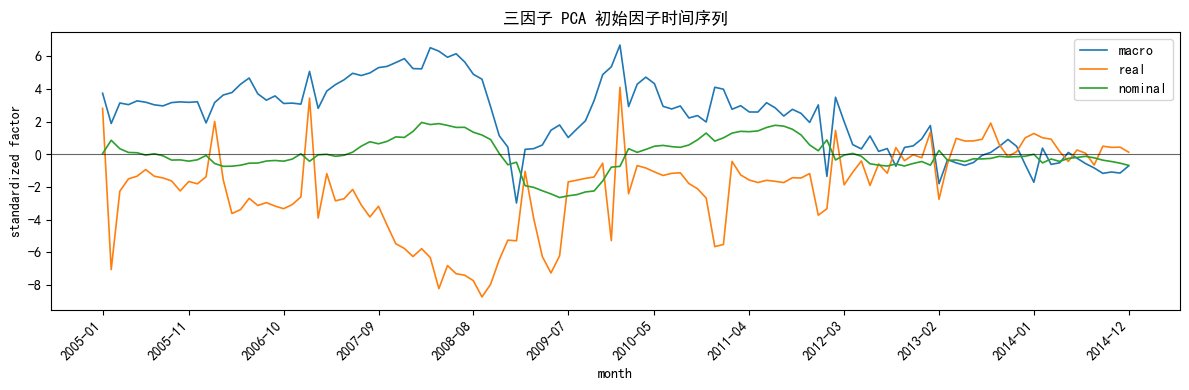

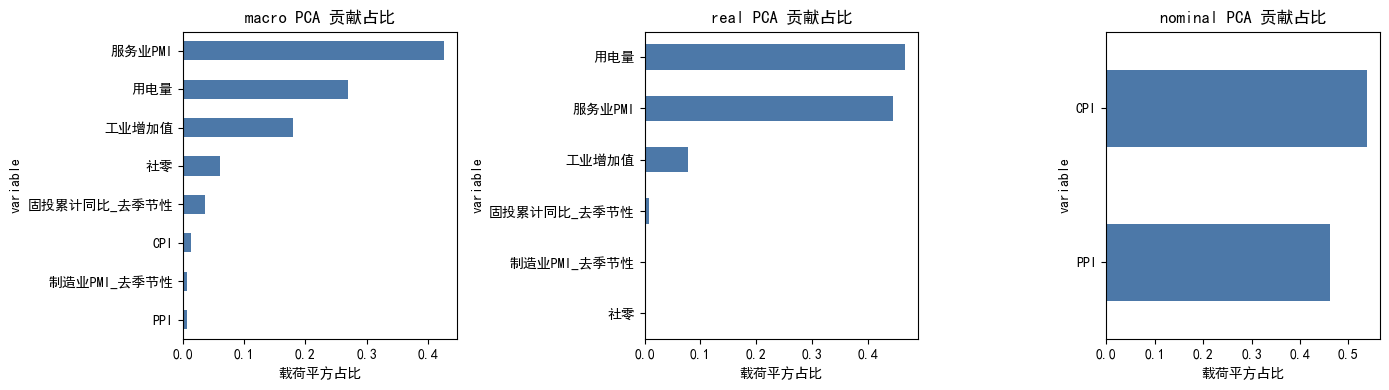

初始 AR 参数前 5 阶：


,rho_1,rho_2,rho_3,rho_4,rho_5
macro,0.583558,0.329828,0.091591,-0.038829,-0.069555
real,0.362019,0.273903,0.069103,0.065269,0.073658
nominal,0.833361,0.315637,0.023145,-0.090107,-0.187292


In [213]:
def first_pc(panel, ref=None):
    bal = panel.dropna()
    if bal.shape[0] < 12 or bal.shape[1] == 0:
        fallback = panel.mean(axis=1, skipna=True).fillna(0.0)
        return fallback, pd.Series(1.0, index=panel.columns)
    mean = bal.mean(axis=0)
    X = bal.to_numpy(float) - mean.to_numpy()[None, :]
    u, s, vt = np.linalg.svd(X, full_matrices=False)
    fac = pd.Series(np.sqrt(len(bal)) * u[:, 0], index=bal.index)
    lam = pd.Series(X.T @ fac.to_numpy() / len(bal), index=bal.columns)
    if ref in bal.columns and fac.corr(bal[ref]) < 0:
        fac = -fac
        lam = -lam
    cen = panel[lam.index] - mean
    denom = lam.pow(2)
    denom_available = cen.notna().mul(denom, axis=1).sum(axis=1)
    proj = cen.mul(lam, axis=1).sum(axis=1, skipna=True) / denom_available
    return proj.replace([np.inf, -np.inf], np.nan).interpolate(limit_direction='both').fillna(0.0), lam


def subtract_factor_component(panel, factor, lam):
    aligned_lam = lam.reindex(panel.columns).fillna(0.0)
    fitted = pd.DataFrame(
        np.outer(factor.reindex(panel.index).to_numpy(float), aligned_lam.to_numpy(float)),
        index=panel.index,
        columns=panel.columns,
    )
    return panel - fitted


def pca_diagnostics(panel, lam):
    bal = panel[lam.index].dropna()
    if bal.shape[0] < 12 or bal.shape[1] == 0:
        return np.nan, np.nan, len(bal), bal.shape[1]
    X = bal.to_numpy(float) - bal.mean(axis=0).to_numpy()[None, :]
    _, s, _ = np.linalg.svd(X, full_matrices=False)
    fac = (X @ lam.to_numpy(float)) / max(float(lam.pow(2).sum()), 1e-12)
    fitted = np.outer(fac, lam.to_numpy(float))
    explained = float(s[0] ** 2 / np.sum(s ** 2)) if np.sum(s ** 2) > 0 else np.nan
    objective = float(np.mean((X - fitted) ** 2))
    return explained, objective, len(bal), bal.shape[1]


init_cols = {'macro': MACRO_COLS, 'real': REAL_COLS, 'nominal': NOMINAL_COLS}
refs = {'macro': '工业增加值', 'real': '工业增加值', 'nominal': 'PPI'}
alpha0 = {}
pca_lam = {}
pca_source_panels = {}
pca_methods = {}

# 1. Global / macro factor: first PC from all selected monthly indicators.
pca_source_panels['macro'] = z[init_cols['macro']]
alpha0['macro'], pca_lam['macro'] = first_pc(pca_source_panels['macro'], refs.get('macro'))
alpha0['macro'] = alpha0['macro'].reindex(z.index).interpolate(limit_direction='both').fillna(0.0)
pca_methods['macro'] = 'global_first_pc_all_monthly'

# 2. Block factors: first PC from residual panels after removing the macro component.
for f in ['real', 'nominal']:
    raw_panel = z[init_cols[f]]
    pca_source_panels[f] = subtract_factor_component(raw_panel, alpha0['macro'], pca_lam['macro'])
    alpha0[f], pca_lam[f] = first_pc(pca_source_panels[f], refs.get(f))
    alpha0[f] = alpha0[f].reindex(z.index).interpolate(limit_direction='both').fillna(0.0)
    pca_methods[f] = f'residual_{f}_first_pc_after_macro'

pca_summary_rows = []
pca_contrib_rows = []
for f in FACTOR_NAMES:
    panel_f = pca_source_panels[f]
    lam = pca_lam[f]
    explained, objective, balanced_rows, balanced_cols = pca_diagnostics(panel_f, lam)
    ref_corr = float(alpha0[f].corr(panel_f[refs[f]])) if refs[f] in panel_f.columns else np.nan
    pca_summary_rows.append({
        'factor': f,
        'method': pca_methods[f],
        'reference_variable': refs.get(f),
        'reference_corr': ref_corr,
        'balanced_rows': balanced_rows,
        'balanced_cols': balanced_cols,
        'explained_ratio_1': explained,
        'pca_objective_v': objective,
    })
    square = lam.pow(2)
    total = float(square.sum())
    balanced_columns = panel_f.dropna().columns
    for col in lam.index:
        pca_contrib_rows.append({
            'factor': f,
            'variable': col,
            '载荷lambda': float(lam.loc[col]),
            '载荷绝对值': float(abs(lam.loc[col])),
            '载荷平方': float(square.loc[col]),
            '观测数': int(panel_f[col].notna().sum()),
            '缺失率': float(panel_f[col].isna().mean()),
            '进入平衡PCA块': bool(col in balanced_columns),
            '贡献占比': float(square.loc[col] / total) if total > 0 else np.nan,
        })
pca_summary = pd.DataFrame(pca_summary_rows)
pca_contribution_table = pd.DataFrame(pca_contrib_rows)
pca_contribution_table['贡献排名'] = pca_contribution_table.groupby('factor')['贡献占比'].rank(ascending=False, method='min').astype('Int64')
pca_contribution_table = pca_contribution_table.sort_values(['factor', '贡献占比'], ascending=[True, False])

print('三因子 PCA 初始化方式：先全体月度变量提取 macro/global 因子，再对扣除 macro 后的 real/nominal 残差分别提取第一主成分；PCA 只用于 EM 初始值。')
display(pca_summary)
print('各变量对对应 PCA 第一主成分的贡献，按载荷平方占比排序：')
display(pca_contribution_table)

alpha0_df = pd.DataFrame(alpha0)
display(alpha0_df.describe().T)
fig, ax = plt.subplots(figsize=(12, 4))
plot_alpha = alpha0_df.loc[TRAIN_START:TRAIN_END].copy(); plot_alpha.index = plot_alpha.index.astype(str)
plot_alpha.plot(ax=ax, linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
tick_positions = np.linspace(0, len(plot_alpha.index) - 1, min(12, len(plot_alpha.index)), dtype=int)
ax.set_xticks(tick_positions); ax.set_xticklabels([plot_alpha.index[i] for i in tick_positions], rotation=45, ha='right')
ax.set_title('三因子 PCA 初始因子时间序列')
ax.set_ylabel('standardized factor')
fig.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(FACTOR_NAMES), figsize=(14, 4), sharex=False)
if len(FACTOR_NAMES) == 1: axes = [axes]
for ax, f in zip(axes, FACTOR_NAMES):
    plot_contrib = pca_contribution_table.loc[pca_contribution_table['factor'] == f].set_index('variable')['贡献占比'].sort_values(ascending=True)
    plot_contrib.plot(kind='barh', ax=ax, color='#4c78a8')
    ax.set_title(f'{f} PCA 贡献占比')
    ax.set_xlabel('载荷平方占比')
fig.tight_layout(); plt.show()


def ar_ols(y, p):
    v = y.astype(float).interpolate(limit_direction='both').fillna(0.0).to_numpy(); X = []; Y = []
    for t in range(p, len(v)): X.append(v[t-p:t][::-1]); Y.append(v[t])
    X = np.asarray(X); Y = np.asarray(Y)
    if len(Y) <= p or np.linalg.matrix_rank(X) == 0:
        rho = np.zeros(p); rho[0] = 0.8
    else: rho = np.linalg.solve(X.T @ X + 1e-6 * np.eye(p), X.T @ Y)
    return pd.Series(rho, index=[f'rho_{i}' for i in range(1, p + 1)])


def accum(a):
    out = []; prev = 0.0
    for m, x in a.items():
        val = sw(m) * prev + float(x); out.append(val); prev = val
    return pd.Series(out, index=a.index)


ar = pd.DataFrame({f: ar_ols(alpha0[f], FACTOR_AR_ORDER) for f in FACTOR_NAMES}).T
S0 = {f: accum(alpha0[f]) for f in FACTOR_NAMES}
xi0 = pd.DataFrame(0.0, index=z.index, columns=STATE_NAMES)
for f in FACTOR_NAMES:
    xi0[f'{f}_alpha_t'] = alpha0[f]
    for lag in range(1, FACTOR_AR_ORDER): xi0[f'{f}_alpha_lag{lag}'] = alpha0[f].shift(lag).bfill().fillna(0.0)
    xi0[s_name(f)] = S0[f]
print('初始 AR 参数前 5 阶：')
display(ar.iloc[:, :5])


PCA 结果分析：
1. 这里展示的是三个初始因子，不是最终 EM 平滑因子。
2. `macro` 反映所有月度变量的共同波动，`real` 更偏实际活动，`nominal` 更偏价格变量。
3. PCA 贡献占比只解释初始化来源，不等同于最终三因子 loading 或 GDP 解释贡献。

### 9.2 累加器与高阶状态初始值

根据 Harvey 递推累加器：

$$
S_t^{(0)} = s_t S_{t-1}^{(0)} + \alpha_t^{(0)}
$$

同时参考论文中有限阶动态因子设定，将状态向量扩展为：

$$
\xi_t^{(0)} =
\begin{bmatrix}
\alpha_t^{(0)} & \alpha_{t-1}^{(0)} & \cdots & \alpha_{t-p+1}^{(0)} & S_t^{(0)}
\end{bmatrix}'
$$

其中 `FACTOR_AR_ORDER = p`。










三因子版对每个因子分别递推一个 `S_t`，并把三个因子的 AR lag 和累加器拼接成完整状态向量。

In [214]:
display(xi0.loc[TRAIN_START:TRAIN_START + 5, STATE_NAMES])


,macro_alpha_t,macro_alpha_lag1,macro_alpha_lag2,macro_alpha_lag3,macro_alpha_lag4,macro_alpha_lag5,macro_alpha_lag6,macro_alpha_lag7,macro_alpha_lag8,macro_alpha_lag9,macro_alpha_lag10,macro_alpha_lag11,macro_alpha_lag12,macro_alpha_lag13,macro_alpha_lag14,macro_S_t,real_alpha_t,real_alpha_lag1,real_alpha_lag2,real_alpha_lag3,real_alpha_lag4,real_alpha_lag5,real_alpha_lag6,real_alpha_lag7,real_alpha_lag8,real_alpha_lag9,real_alpha_lag10,real_alpha_lag11,real_alpha_lag12,real_alpha_lag13,real_alpha_lag14,real_S_t,nominal_alpha_t,nominal_alpha_lag1,nominal_alpha_lag2,nominal_alpha_lag3,nominal_alpha_lag4,nominal_alpha_lag5,nominal_alpha_lag6,nominal_alpha_lag7,nominal_alpha_lag8,nominal_alpha_lag9,nominal_alpha_lag10,nominal_alpha_lag11,nominal_alpha_lag12,nominal_alpha_lag13,nominal_alpha_lag14,nominal_S_t
month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2005-01,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917
2005-02,1.885446,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,5.625961,-7.062412,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,-4.248531,0.861370,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.901286
2005-03,3.143306,1.885446,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,8.769267,-2.261419,-7.062412,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,-6.509949,0.341803,0.861370,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,1.243089
2005-04,3.042887,3.143306,1.885446,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.042887,-1.505180,-2.261419,-7.062412,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,-1.505180,0.114189,0.341803,0.861370,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.114189
2005-05,3.273741,3.042887,3.143306,1.885446,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,6.316628,-1.340221,-1.505180,-2.261419,-7.062412,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,-2.845401,0.095702,0.114189,0.341803,0.861370,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.209891
2005-06,3.191420,3.273741,3.042887,3.143306,1.885446,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,3.740515,9.508048,-0.934288,-1.340221,-1.505180,-2.261419,-7.062412,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,2.813881,-3.779689,-0.049827,0.095702,0.114189,0.341803,0.861370,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.039917,0.160064


### 9.3 状态转移参数初始值：AR(p)

参考论文的有限阶动态因子设定，令初始因子满足：

$$
\alpha_t^{(0)} = \rho_1^{(0)}\alpha_{t-1}^{(0)} + \rho_2^{(0)}\alpha_{t-2}^{(0)} + \cdots + \rho_p^{(0)}\alpha_{t-p}^{(0)} + u_t
$$

用 OLS 得到初始 AR(p) 系数。共同因子冲击方差继续采用文献归一化：

$$
Var(u_t)=1
$$

因此残差方差只作为诊断值保留，不作为 Kalman filter 的 $Q_t$ 输入。










三因子版分别对 `macro`、`real`、`nominal` 三个 PCA 初始因子估计 AR(15) 初始参数。

In [215]:
def companion_matrix_from_ar_values(values: np.ndarray) -> np.ndarray:
    p = len(values)
    companion = np.zeros((p, p), dtype=float)
    companion[0, :] = values
    if p > 1:
        companion[1:, :-1] = np.eye(p - 1)
    return companion

def ar_spectral_radius_values(values: np.ndarray) -> float:
    eigvals = np.linalg.eigvals(companion_matrix_from_ar_values(values))
    return float(np.max(np.abs(eigvals))) if len(eigvals) else 0.0

ar_init_summary = ar.copy()
ar_init_summary['spectral_radius_diagnostic_no_clip'] = [ar_spectral_radius_values(ar.loc[f].to_numpy(float)) for f in FACTOR_NAMES]
STATE_SHOCK_VARIANCE = 1.0
print(f'state shock variance: {STATE_SHOCK_VARIANCE:.1f}; AR clip=False')
display(ar_init_summary)


state shock variance: 1.0; AR clip=False


,rho_1,rho_2,rho_3,rho_4,rho_5,rho_6,rho_7,rho_8,rho_9,rho_10,rho_11,rho_12,rho_13,rho_14,rho_15,spectral_radius_diagnostic_no_clip
macro,0.583558,0.329828,0.091591,-0.038829,-0.069555,0.006913,0.012202,0.062129,-0.021788,-0.096133,0.044754,-0.310643,0.297947,0.126391,-0.056012,0.983086
real,0.362019,0.273903,0.069103,0.065269,0.073658,0.147741,0.058523,0.009489,-0.069356,-0.103390,0.159083,-0.126998,0.039947,0.040620,-0.070692,0.956814
nominal,0.833361,0.315637,0.023145,-0.090107,-0.187292,0.006311,0.004337,0.017065,-0.000837,-0.093614,0.201890,-0.493496,0.339645,0.140646,-0.161553,0.965899


### 9.4 月度变量载荷与误差方差初始值

对每个月度宏观变量单独回归：

$$
x_{i,t} = \lambda_i^{(0)} \alpha_t^{(0)} + \varepsilon_{i,t}
$$

用 OLS 得到：

$$
\lambda_i^{(0)} =
\frac{\sum_t \alpha_t^{(0)} x_{i,t}}{\sum_t (\alpha_t^{(0)})^2}
$$

月度变量误差方差初始值：

$$
h_i^{(0)} = Var\left(x_{i,t} - \lambda_i^{(0)}\alpha_t^{(0)}\right)
$$









三因子版对每个变量只在允许的因子集合内做 OLS 初始化；不允许加载的因子 loading 固定为 0。

In [216]:
def solve_beta(X,y):
    X=np.asarray(X,float); y=np.asarray(y,float)
    if X.ndim==1: X=X[:,None]
    ok=np.isfinite(y)&np.all(np.isfinite(X),axis=1); X=X[ok]; y=y[ok]
    if len(y)==0: return np.zeros(X.shape[1])
    return np.linalg.solve(X.T@X+1e-6*np.eye(X.shape[1]),X.T@y)
def init_loading_h():
    L=pd.DataFrame(0.0,index=model_cols,columns=FACTOR_NAMES); h=pd.Series(1.0,index=model_cols,name='h')
    for c in model_cols:
        fs=allowed[c]; obs=z[c].dropna()
        if c==GDP_COL:
            obs=obs.loc[[m for m in obs.index if q_end(m)]]; X=pd.DataFrame({f:S0[f].reindex(obs.index) for f in fs})
        else:
            X=pd.DataFrame({f:alpha0[f].reindex(obs.index) for f in fs})
        beta=solve_beta(X.to_numpy(),obs.to_numpy())
        for f,b in zip(fs,beta): L.loc[c,f]=b
        resid=obs.to_numpy()-X.to_numpy()@beta; h.loc[c]=max(float(np.nanmean(resid**2)) if len(resid) else 1.0,MIN_H)
    return L.where(mask,0.0),h
L,h=init_loading_h(); display(L); display(h.to_frame())


,macro,real,nominal
GDP同比,0.112809,0.069908,0.000000
服务业PMI,0.782008,-0.538178,0.000000
工业增加值,0.356419,0.250152,0.000000
用电量,0.557383,0.634007,0.000000
社零,-0.008400,-0.166479,0.000000
CPI,0.020017,0.000000,0.917296
PPI,0.081258,0.000000,0.772645
制造业PMI_去季节性,0.212458,0.126613,0.000000
固投累计同比_去季节性,0.079355,-0.061491,0.000000


,h
GDP同比,0.542043
服务业PMI,0.021409
工业增加值,0.298597
用电量,0.159979
社零,0.703244
CPI,0.123371
PPI,0.228690
制造业PMI_去季节性,0.750241
固投累计同比_去季节性,0.816183


### 9.5 GDP 载荷与观测误差方差初始值

GDP 在季度末同时加载三个 Harvey 累加器：

$$
GDP_t^{std} = \lambda^{macro}_{GDP}S^{macro}_t + \lambda^{real}_{GDP}S^{real}_t + \lambda^{nominal}_{GDP}S^{nominal}_t + \varepsilon_{GDP,t}
$$

初始 GDP loading 由季度末 GDP 对三个初始累加器的无截距 OLS 得到。

In [217]:
gdp_param_init = pd.Series({
    **{f'lambda_gdp_{f}_init': float(L.loc[GDP_COL, f]) for f in FACTOR_NAMES},
    'h_gdp_init': float(h.loc[GDP_COL]),
    'gdp_obs_used': int(z.loc[[m for m in z.index if q_end(m)], GDP_COL].dropna().shape[0]),
})
display(gdp_param_init.to_frame('value'))


,value
lambda_gdp_macro_init,0.112809
lambda_gdp_real_init,0.069908
lambda_gdp_nominal_init,0.000000
h_gdp_init,0.542043
gdp_obs_used,40.000000


### 9.6 汇总初始对象

后续 Kalman filter 需要的初始对象包括：

$$
\xi_t^{(0)},\quad \rho_1^{(0)},\ldots,\rho_p^{(0)},\quad Var(u_t)=1,\quad \lambda_i^{(0)},\quad h_i^{(0)},\quad h_{GDP}^{(0)}
$$

这里先构造完整观测误差协方差初始矩阵：

$$
H^{(0)} = diag\left(h_{GDP}^{(0)}, h_1^{(0)}, h_2^{(0)}, \ldots, h_N^{(0)}\right)
$$

注意：$H^{(0)}$ 仍然是初始值。后续 EM 更新时，$H$ 要使用 smoother 给出的状态均值和状态协方差来更新。










In [218]:
H_init = pd.DataFrame(np.diag(h.loc[model_cols_valid].to_numpy(float)), index=model_cols_valid, columns=model_cols_valid)
initialization_artifacts = {
    'alpha_init': alpha0_df,
    'S_init': pd.DataFrame(S0),
    'xi_init': xi0,
    'ar_params_init': ar,
    'pca_block_loadings': pca_lam,
    'pca_summary': pca_summary,
    'state_shock_variance': STATE_SHOCK_VARIANCE,
    'loading_init': L,
    'h_init': h,
    'H_init': H_init,
}
print('Initialization objects generated:')
print(', '.join(initialization_artifacts.keys()))
display(pd.concat([L.add_prefix('lambda_'), h.rename('h_init')], axis=1))


Initialization objects generated:
alpha_init, S_init, xi_init, ar_params_init, pca_block_loadings, pca_summary, state_shock_variance, loading_init, h_init, H_init


,lambda_macro,lambda_real,lambda_nominal,h_init
GDP同比,0.112809,0.069908,0.000000,0.542043
服务业PMI,0.782008,-0.538178,0.000000,0.021409
工业增加值,0.356419,0.250152,0.000000,0.298597
用电量,0.557383,0.634007,0.000000,0.159979
社零,-0.008400,-0.166479,0.000000,0.703244
CPI,0.020017,0.000000,0.917296,0.123371
PPI,0.081258,0.000000,0.772645,0.228690
制造业PMI_去季节性,0.212458,0.126613,0.000000,0.750241
固投累计同比_去季节性,0.079355,-0.061491,0.000000,0.816183


### 9.7 各观测变量自身的 AR(15) 诊断

主模型的状态转移只使用共同因子 $\alpha_t^{(0)}$ 的 AR(15) 初始化。这里额外对每个观测变量自身估计一次无截距 AR(15)，仅用于诊断变量自身的持续性：

$$
x_{i,t} = \phi_{i,1}x_{i,t-1}+\phi_{i,2}x_{i,t-2}+\cdots+\phi_{i,15}x_{i,t-15}+u_{i,t}
$$

缺失值较多的变量可能没有足够连续样本，表中会标记为估计失败。

In [219]:
observed_ar15_rows = []
for col in model_cols_valid:
    series = z_train_df[col].astype(float).dropna()
    row = {'variable': col, 'n_obs': int(series.shape[0]), 'ar_effective_rows': 0, 'estimated': False, 'spectral_radius': np.nan, 'note': ''}
    try:
        coef = ar_ols(series.reindex(z_train_df.index).interpolate(limit_direction='both').fillna(0.0), FACTOR_AR_ORDER)
        row['ar_effective_rows'] = max(int(series.shape[0] - FACTOR_AR_ORDER), 0)
        row['estimated'] = True
        row['spectral_radius'] = ar_spectral_radius_values(coef.to_numpy(float))
    except Exception as exc:
        row['note'] = str(exc)
    observed_ar15_rows.append(row)
observed_ar15_summary = pd.DataFrame(observed_ar15_rows).set_index('variable')
display(observed_ar15_summary)


,n_obs,ar_effective_rows,estimated,spectral_radius,note
variable,,,,,
GDP同比,40,25,True,0.945308,
服务业PMI,35,20,True,0.988360,
工业增加值,120,105,True,0.950684,
用电量,56,41,True,0.961529,
社零,118,103,True,0.968832,
CPI,120,105,True,0.975242,
PPI,120,105,True,0.961392,
制造业PMI_去季节性,120,105,True,0.945631,
固投累计同比_去季节性,110,95,True,0.986386,


## 10. 构造 Kalman filter 系统矩阵

本节按文献附录 A.1-A.2 的口径，先把每一期 Kalman filter 需要的状态方程和观测方程矩阵组装出来。

文献状态方程写作：

$$
\alpha_{t+1}=T_t\alpha_t+R_t\eta_t,
\qquad
\eta_t\sim N(0,Q)
$$

本文 notebook 的状态向量是月频版本：

$$
\xi_t=
\begin{bmatrix}
\alpha_t & \alpha_{t-1} & \cdots & \alpha_{t-p+1} & S_t
\end{bmatrix}'
$$

其中 $S_t$ 是季度 GDP 对应的 Harvey sum accumulator：

$$
S_t=s_t S_{t-1}+\alpha_t
$$

观测方程为：

$$
y_t=Z_t\xi_t+\varepsilon_t,
\qquad
\varepsilon_t\sim N(0,H)
$$

由于每期有些变量缺失，文献用选择矩阵 $W_t$ 处理部分观测：

$$
y_t^*=W_t y_t
$$

$$
Z_t^*=W_t Z_t
$$

$$
H_t^*=W_t H W_t'
$$

所以本节输出的核心对象是：

$$
T_t,\quad Q_t,\quad y_t^*,\quad Z_t^*,\quad H_t^*,\quad W_t
$$

**与原文的必要差异**

1. 原文是周频金融条件指数，状态中有 monthly average、monthly sum、quarterly sum 三个 accumulator；本 notebook 是月频宏观变量和季度 GDP，因此只保留季度 sum accumulator $S_t$。
2. 原文记号用 $\alpha_t$ 表示整个状态；本 notebook 为了区分共同因子和状态向量，用 $\xi_t$ 表示状态向量，用 $\alpha_t$ 表示状态向量里的当期共同因子。
3. 原文将状态扰动方差归一化；本 notebook 同样设 $Var(\eta_t)=1$。

In [220]:
def build_state_transition_system(month: pd.Period, ar_params: pd.DataFrame):
    F_t = pd.DataFrame(trans(month, ar_params), index=STATE_NAMES, columns=STATE_NAMES)
    Q_t = pd.DataFrame(Q, index=STATE_NAMES, columns=STATE_NAMES)
    return F_t, Q_t

example_month = TRAIN_START
F_example, Q_example = build_state_transition_system(example_month, ar)
Z_example = obs_mat(example_month, L)
print(f'Example month: {example_month}; state_dim={len(STATE_NAMES)}; observed_dim={len(model_cols_valid)}')
display(F_example.iloc[:8, :8])
display(Q_example.iloc[:8, :8])
display(Z_example.loc[model_cols_valid, Z_example.columns[Z_example.abs().sum(axis=0) > 0]])


Example month: 2005-01; state_dim=48; observed_dim=9


,macro_alpha_t,macro_alpha_lag1,macro_alpha_lag2,macro_alpha_lag3,macro_alpha_lag4,macro_alpha_lag5,macro_alpha_lag6,macro_alpha_lag7
macro_alpha_t,0.583558,0.329828,0.091591,-0.038829,-0.069555,0.006913,0.012202,0.062129
macro_alpha_lag1,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
macro_alpha_lag2,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
macro_alpha_lag3,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
macro_alpha_lag4,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
macro_alpha_lag5,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
macro_alpha_lag6,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
macro_alpha_lag7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000


,macro_alpha_t,macro_alpha_lag1,macro_alpha_lag2,macro_alpha_lag3,macro_alpha_lag4,macro_alpha_lag5,macro_alpha_lag6,macro_alpha_lag7
macro_alpha_t,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
macro_alpha_lag7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,macro_alpha_t,real_alpha_t,nominal_alpha_t
GDP同比,0.000000,0.000000,0.000000
服务业PMI,0.782008,-0.538178,0.000000
工业增加值,0.356419,0.250152,0.000000
用电量,0.557383,0.634007,0.000000
社零,-0.008400,-0.166479,0.000000
CPI,0.020017,0.000000,0.917296
PPI,0.081258,0.000000,0.772645
制造业PMI_去季节性,0.212458,0.126613,0.000000
固投累计同比_去季节性,0.079355,-0.061491,0.000000


## 11. Kalman Filter Forward Recursion

This section follows the Durbin and Koopman notation used in Appendix A.1 of the paper. Given $a_t$ and $P_t$:

$$
v_t = y_t - Z_t a_t
$$

$$
F_t = Z_tP_tZ_t' + H
$$

$$
K_t = T_tP_tZ_t'F_t^{-1}
$$

$$
L_t = T_t - K_tZ_t
$$

$$
a_{t+1} = T_ta_t + K_tv_t
$$

$$
P_{t+1} = T_tP_tL_t' + RQR'
$$

With missing observations, the code uses the selected system:

$$
y_t^*,\quad Z_t^*,\quad H_t^*
$$

so that:

$$
v_t = y_t^* - Z_t^* a_t
$$

$$
F_t^* = Z_t^*P_tZ_t^{*'} + H_t^*
$$

In code, `Omega_t` is the paper's $F_t^*$, named differently to avoid collision with the transition matrix. The log likelihood follows paper Eq. (4), omitting the normal constant.


In [221]:
def pinv_solve(A, B):
    try:
        return np.linalg.solve(A, B)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(A) @ B


def _solve_symmetric(A, B):
    A = 0.5 * (A + A.T)
    try:
        return np.linalg.solve(A, B)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(A) @ B


def _safe_slogdet(A):
    A = 0.5 * (A + A.T)
    sign, logdet = np.linalg.slogdet(A)
    if sign > 0:
        return float(logdet)
    jitter = 1e-10 * max(float(np.nanmax(np.abs(np.diag(A)))) if A.size else 1.0, 1.0)
    for _ in range(6):
        sign, logdet = np.linalg.slogdet(A + jitter * np.eye(A.shape[0]))
        if sign > 0:
            return float(logdet)
        jitter *= 10.0
    return float(np.log(max(np.linalg.det(A + jitter * np.eye(A.shape[0])), 1e-12)))


FACTOR_POS = {f: i for i, f in enumerate(FACTOR_NAMES)}
FACTOR_ALPHA_POS = {f: pos[f'{f}_alpha_t'] for f in FACTOR_NAMES}
FACTOR_S_POS = {f: pos[s_name(f)] for f in FACTOR_NAMES}
FACTOR_AR_POS = {f: np.array([pos[n] for n in FACTOR_A[f]], dtype=int) for f in FACTOR_NAMES}
MODEL_COL_POS = {c: i for i, c in enumerate(model_cols)}

TARGET_STATE_POS = {}
TARGET_FACTOR_POS = {}
for c in model_cols:
    if c == GDP_COL:
        TARGET_STATE_POS[c] = np.array([FACTOR_S_POS[f] for f in allowed[c]], dtype=int)
    else:
        TARGET_STATE_POS[c] = np.array([FACTOR_ALPHA_POS[f] for f in allowed[c]], dtype=int)
    TARGET_FACTOR_POS[c] = np.array([FACTOR_POS[f] for f in allowed[c]], dtype=int)


def _build_fast_panel_cache(panel):
    months = list(panel.index)
    y = panel.loc[months, model_cols].to_numpy(float)
    obs_idx = [np.flatnonzero(np.isfinite(y[i])) for i in range(len(months))]
    q_end_flags = np.array([q_end(m) for m in months], dtype=bool)
    q_start_flags = np.array([q_start(m) for m in months], dtype=bool)
    obs_for_update = {}
    for c in model_cols:
        j = MODEL_COL_POS[c]
        valid = np.flatnonzero(np.isfinite(y[:, j]))
        if c == GDP_COL:
            valid = np.array([i for i in valid if q_end_flags[i]], dtype=int)
        obs_for_update[c] = valid
    return {
        'months': months,
        'y': y,
        'obs_idx': obs_idx,
        'q_end': q_end_flags,
        'q_start': q_start_flags,
        'obs_for_update': obs_for_update,
    }


def _transition_array(month_is_q_start, ar_values):
    T = np.zeros((nstate, nstate), dtype=float)
    st = 0.0 if month_is_q_start else 1.0
    for f in FACTOR_NAMES:
        ap = FACTOR_AR_POS[f]
        sp = FACTOR_S_POS[f]
        rho = ar_values[FACTOR_POS[f]]
        T[ap[0], ap] = rho
        for lag in range(1, FACTOR_AR_ORDER):
            T[ap[lag], ap[lag - 1]] = 1.0
        T[sp, ap] = rho
        T[sp, sp] = st
    return T


def _loading_array(L):
    return L.reindex(index=model_cols, columns=FACTOR_NAMES).fillna(0.0).to_numpy(float)


def _h_array(h):
    return h.reindex(model_cols).fillna(1.0).to_numpy(float)


def _ar_array(ar):
    return ar.reindex(index=FACTOR_NAMES, columns=[f'rho_{i}' for i in range(1, FACTOR_AR_ORDER + 1)]).fillna(0.0).to_numpy(float)


def _observed_Z(obs, q_end_flag, L_arr):
    Z = np.zeros((len(obs), nstate), dtype=float)
    for r, j in enumerate(obs):
        c = model_cols[j]
        if c == GDP_COL and not q_end_flag:
            continue
        state_idx = TARGET_STATE_POS[c]
        factor_idx = TARGET_FACTOR_POS[c]
        Z[r, state_idx] = L_arr[j, factor_idx]
    return Z


def kfilter_fast(panel_cache, ar, L, h, a1=None, P1=None):
    months = panel_cache['months']; n = len(months)
    y = panel_cache['y']; obs_idx = panel_cache['obs_idx']
    ar_arr = _ar_array(ar); L_arr = _loading_array(L); h_arr = _h_array(h)
    ap = np.zeros((n, nstate), dtype=float); Pp = np.zeros((n, nstate, nstate), dtype=float)
    af = np.zeros((n, nstate), dtype=float); Pf = np.zeros((n, nstate, nstate), dtype=float)
    Ts = np.zeros((n, nstate, nstate), dtype=float)
    a = np.zeros(nstate, dtype=float) if a1 is None else np.asarray(a1, dtype=float).copy()
    P = np.eye(nstate, dtype=float) * 10.0 if P1 is None else np.asarray(P1, dtype=float).copy()
    ll = 0.0
    eye_cache = {}
    for i in range(n):
        if i == 0:
            T = np.eye(nstate, dtype=float)
        else:
            T = _transition_array(panel_cache['q_start'][i], ar_arr)
            a = T @ a
            P = T @ P @ T.T + Q
            P = 0.5 * (P + P.T)
        Ts[i] = T; ap[i] = a; Pp[i] = P
        obs = obs_idx[i]
        if len(obs):
            Z = _observed_Z(obs, panel_cache['q_end'][i], L_arr)
            yv = y[i, obs]
            H = np.diag(np.maximum(h_arr[obs], MIN_H))
            v = yv - Z @ a
            F = Z @ P @ Z.T + H
            F = 0.5 * (F + F.T)
            invv = _solve_symmetric(F, v)
            Finv_ZP = _solve_symmetric(F, Z @ P)
            K = Finv_ZP.T
            ll += -0.5 * (_safe_slogdet(F) + float(v.T @ invv))
            a = a + K @ v
            P = P - K @ Z @ P
            P = 0.5 * (P + P.T)
        af[i] = a; Pf[i] = P
    return {'months': months, 'ap': ap, 'Pp': Pp, 'af': af, 'Pf': Pf, 'Ts': Ts, 'loglike': float(ll), 'panel_cache': panel_cache}


def smooth_fast(fr, return_frames=False):
    months = fr['months']; n = len(months)
    a = fr['af'].copy(); P = fr['Pf'].copy()
    for i in range(n - 2, -1, -1):
        J = fr['Pf'][i] @ fr['Ts'][i + 1].T @ np.linalg.pinv(fr['Pp'][i + 1])
        a[i] = fr['af'][i] + J @ (a[i + 1] - fr['ap'][i + 1])
        P[i] = fr['Pf'][i] + J @ (P[i + 1] - fr['Pp'][i + 1]) @ J.T
        P[i] = 0.5 * (P[i] + P[i].T)
    out = {'state_array': a, 'cov_array': P, 'months': months}
    if return_frames:
        out['state'] = pd.DataFrame(a, index=months, columns=STATE_NAMES)
        out['cov'] = {m: pd.DataFrame(P[i], index=STATE_NAMES, columns=STATE_NAMES) for i, m in enumerate(months)}
    return out


def _ar_ols_array(v, p):
    v = np.asarray(v, dtype=float)
    X = []; Y = []
    for t in range(p, len(v)):
        X.append(v[t - p:t][::-1]); Y.append(v[t])
    X = np.asarray(X, dtype=float); Y = np.asarray(Y, dtype=float)
    if len(Y) <= p or np.linalg.matrix_rank(X) == 0:
        rho = np.zeros(p, dtype=float); rho[0] = 0.8
    else:
        rho = np.linalg.solve(X.T @ X + 1e-6 * np.eye(p), X.T @ Y)
    return rho


def update_ar_fast(state_array):
    arr = np.zeros((len(FACTOR_NAMES), FACTOR_AR_ORDER), dtype=float)
    for f in FACTOR_NAMES:
        arr[FACTOR_POS[f]] = _ar_ols_array(state_array[:, FACTOR_ALPHA_POS[f]], FACTOR_AR_ORDER)
    return pd.DataFrame(arr, index=FACTOR_NAMES, columns=[f'rho_{i}' for i in range(1, FACTOR_AR_ORDER + 1)])


def update_L_h_fast(panel_cache, state_array, cov_array):
    y = panel_cache['y']
    L_arr = np.zeros((len(model_cols), len(FACTOR_NAMES)), dtype=float)
    h_new = np.ones(len(model_cols), dtype=float)
    for c in model_cols:
        j = MODEL_COL_POS[c]
        obs = panel_cache['obs_for_update'][c]
        if len(obs) == 0:
            h_new[j] = 1.0
            continue
        states = TARGET_STATE_POS[c]
        factors = TARGET_FACTOR_POS[c]
        k = len(states)
        num = np.zeros(k, dtype=float)
        den = np.zeros((k, k), dtype=float)
        for i in obs:
            mu = state_array[i, states]
            V = cov_array[i][np.ix_(states, states)]
            num += float(y[i, j]) * mu
            den += V + np.outer(mu, mu)
        beta = pinv_solve(den + 1e-8 * np.eye(k), num)
        L_arr[j, factors] = beta
        hs = 0.0
        for i in obs:
            yy = float(y[i, j])
            mu = state_array[i, states]
            V = cov_array[i][np.ix_(states, states)]
            second = V + np.outer(mu, mu)
            hs += yy ** 2 - 2.0 * yy * float(beta @ mu) + float(beta @ second @ beta)
        h_new[j] = max(float(hs / len(obs)), MIN_H)
    Lnew = pd.DataFrame(L_arr, index=model_cols, columns=FACTOR_NAMES).where(mask, 0.0)
    hnew = pd.Series(h_new, index=model_cols, name='h')
    return Lnew, hnew


def m_step_fast(panel_cache, state_array, cov_array, ar_params_old=None, loading_old=None, h_old=None):
    """One three-factor EM M-step on fast numpy arrays.

    This keeps the same public function name used by the original single-factor
    notebook while dispatching to the three-factor block-loading updates.
    """
    ar_new = update_ar_fast(state_array)
    loading_new, h_new = update_L_h_fast(panel_cache, state_array, cov_array)
    return {'ar': ar_new, 'loading': loading_new, 'h': h_new}


def run_em_fast(panel, ar0, L0, h0):
    panel_cache = _build_fast_panel_cache(panel)
    ar = ar0.copy(); L = L0.copy(); h = h0.copy()
    a1 = xi0.iloc[0].reindex(STATE_NAMES).fillna(0.0).to_numpy(float)
    P1 = np.eye(nstate, dtype=float) * 10.0
    hist = []
    last = None
    print(f'Fast EM start: tol={TOL:g}, state_dim={nstate}, numpy_loop=True, max_iter=None')
    it = 0
    while True:
        it += 1
        iter_t0 = time.perf_counter()
        t0 = time.perf_counter(); fr = kfilter_fast(panel_cache, ar, L, h, a1, P1); filter_seconds = time.perf_counter() - t0
        t0 = time.perf_counter(); sm = smooth_fast(fr, return_frames=False); smoother_seconds = time.perf_counter() - t0
        t0 = time.perf_counter(); ar2 = update_ar_fast(sm['state_array']); L2, h2 = update_L_h_fast(panel_cache, sm['state_array'], sm['cov_array']); m_step_seconds = time.perf_counter() - t0
        a1_next = sm['state_array'][0].copy()
        ll = fr['loglike']
        rel = np.nan if last is None else abs((ll - last) / max(1.0, abs(last)))
        hist.append({
            'iteration': it,
            'loglike': ll,
            'relative_loglike_change': rel,
            'min_h': float(h2.min()),
            'max_h': float(h2.max()),
            'filter_seconds': filter_seconds,
            'smoother_seconds': smoother_seconds,
            'm_step_seconds': m_step_seconds,
            'iteration_seconds': time.perf_counter() - iter_t0,
        })
        print(f"iter {it:03d}: loglike={ll:.6f}, rel_change={rel}, min_h={h2.min():.3g}, time(filter/smoother/M)={filter_seconds:.2f}/{smoother_seconds:.2f}/{m_step_seconds:.2f}s")
        ar, L, h = ar2, L2, h2
        a1 = a1_next
        if last is not None and rel < TOL:
            break
        last = ll
    fr = kfilter_fast(panel_cache, ar, L, h, a1, P1)
    sm = smooth_fast(fr, return_frames=True)
    return {'ar': ar, 'loading': L, 'h': h, 'a1': pd.Series(a1, index=STATE_NAMES), 'history': pd.DataFrame(hist), 'filter': fr, 'smoother': sm}

# Keep the public entry point unchanged for downstream cells.
run_em = run_em_fast


## 12. Kalman Smoother Backward Recursion

Appendix A.1 uses the $r_t$ and $N_t$ backward smoother with terminal conditions:

$$
r_T=0,
\qquad
N_T=0
$$

Backward recursion:

$$
r_{t-1}=Z_t'F_t^{-1}v_t+L_t'r_t
$$

$$
N_{t-1}=Z_t'F_t^{-1}Z_t+L_t'N_tL_t
$$

Smoothed state and covariance:

$$
\hat{\alpha}_t=a_t+P_tr_{t-1}
$$

$$
V_t=P_t-P_tN_{t-1}P_t
$$

The paper also computes the lag-one covariance needed by the EM M-step:

$$
J_t=P_tL_{t-1}'(I-N_{t-1}P_t)
$$

The code returns `smoothed_state`, `smoothed_cov`, and `lag_one_smoothed_cov` for the M-step.


In [222]:
print('RTS smoother functions are defined together with the fast Kalman implementation in section 11.')


RTS smoother functions are defined together with the fast Kalman implementation in section 11.


## 13. EM M-step Following Appendix A.3

Appendix A.3 maximizes the conditional expectation of the complete-data log likelihood. The smoother supplies:

> $$
> E(\alpha_t\mid Y)=\hat{\alpha}_t
> $$

> $$
> Var(\alpha_t\mid Y)=V_t
> $$

> $$
> Cov(\alpha_t,\alpha_{t-1}\mid Y)=J_t'
> $$

The paper's update equations are:

> $$
> T^{new}=BA^{-1}
> $$

> $$
> Z^{new}=ED^{-1}
> $$

Under the restricted measurement structure, each indicator loads on one state element, so loadings and diagonal $H_i$ are updated variable by variable. The EM loop also updates $a_1$ to the first smoothed state and keeps $P_1$ at the baseline initial covariance, as described in Appendix A.3.


### 13.1 Update Transition Dynamics AR(p)

The unrestricted paper update is:

> $$
> T^{new}=BA^{-1}
> $$

For the first row of the AR(15) companion block, define:

> $$
> \alpha_t=\rho_1\alpha_{t-1}+\rho_2\alpha_{t-2}+\cdots+\rho_p\alpha_{t-p}+u_t
> $$

> $$
> x_{t-1}=\begin{bmatrix}\alpha_{t-1} & \alpha_{t-2} & \cdots & \alpha_{t-p}\end{bmatrix}'
> $$

Then the corresponding $BA^{-1}$ update is:

> $$
> \rho^{new}=\left[\sum_t E(x_{t-1}x_{t-1}'\mid Y)\right]^{-1}\left[\sum_t E(x_{t-1}\alpha_t\mid Y)\right]
> $$

The companion spectral radius is reported as a diagnostic only; it is not clipped or rescaled.


In [223]:
print('AR M-step is implemented inside update_ar_fast(...), called by m_step_fast(...).')


AR M-step is implemented inside update_ar_fast(...), called by m_step_fast(...).


### 13.2 更新观测载荷 Z

文献 unrestricted 更新为：

> $$
> Z^{new}=ED^{-1}
> $$

其中：

> $$
> D=\sum_{t=1}^{T}E(\xi_t\xi_t'\mid Y)
> $$

> $$
> E=\sum_{t=1}^{T}y_t\hat{\xi}_t'
> $$

但文献随后说明，在模型受限结构下，每个指标只加载到一个状态元素。若变量 $i$ 加载到状态元素 $j$，则：

> $$
> y_{i,t}=\lambda_i\xi_{j,t}+\varepsilon_{i,t}
> $$

只使用该变量实际有观测的时期 $\mathcal{T}_i$：

> $$
> \lambda_i^{new}
> =
> \frac{
> \sum_{t\in\mathcal{T}_i} y_{i,t}\hat{\xi}_{j,t}
> }{
> \sum_{t\in\mathcal{T}_i}E(\xi_{j,t}^2\mid Y)
> }
> $$

其中：

> $$
> E(\xi_{j,t}^2\mid Y)=\hat{\xi}_{j,t}^2+V_{j,j,t}
> $$

本 notebook 使用同一受限载荷更新：月度变量加载到 $\alpha_t$，GDP 加载到 $S_t$。

In [224]:
print('Loading M-step is implemented inside update_L_h_fast(...), respecting the three-factor loading mask.')


Loading M-step is implemented inside update_L_h_fast(...), respecting the three-factor loading mask.


### 13.3 Update Observation Error Variance H

The paper uses diagonal $H$ and updates each observed variable separately. If variable $i$ loads on state element $j$:

> $$
> H_i^{new}=\frac{1}{T_i}\sum_{t\in\mathcal{T}_i}\left(y_{i,t}-\lambda_i^{new}\hat{\xi}_{j,t}\right)^2
> $$

where $\mathcal{T}_i$ contains only periods in which variable $i$ is observed. The code follows this variable-by-variable mean squared smoothed residual update.


In [225]:
print('Diagonal H update is implemented inside update_L_h_fast(...), with MIN_H lower bound.')


Diagonal H update is implemented inside update_L_h_fast(...), with MIN_H lower bound.


### 13.4 One M-step Summary

One M-step is not the final converged estimate. Full training iterates:

> $$
> \text{Kalman filter}\rightarrow\text{Kalman smoother}\rightarrow\text{M-step}
> $$

until the paper Eq. (4) log likelihood is stable. The convergence threshold is:

> $$
> \left|\frac{\log L^{(k)}-\log L^{(k-1)}}{\left(\log L^{(k)}+\log L^{(k-1)}\right)/2}\right|<10^{-6}
> $$

Replication status:

1. Kalman filter uses the paper's $a_t,P_t,K_t,L_t$ recursion.
2. Kalman smoother uses the paper's $r_t,N_t$ recursion and returns lag-one covariance for the M-step.
3. M-step updates AR(15), $Z$, and diagonal $H$ following Appendix A.3, with $Var(u_t)=1$ normalization.
4. $a_1$ is updated to the first smoothed state; $P_1$ stays at the baseline initial covariance.


In [226]:
panel_cache_check = _build_fast_panel_cache(z.loc[TRAIN_START:TRAIN_END, model_cols_valid])
fr_check = kfilter_fast(panel_cache_check, ar, L, h)
sm_check = smooth_fast(fr_check, return_frames=True)
m_step_check = m_step_fast(panel_cache_check, sm_check['state_array'], sm_check['cov_array'], ar, L, h)
print(f"One-step M-step check: min_h={float(m_step_check['h'].min()):.3g}, max_h={float(m_step_check['h'].max()):.3g}")
display(m_step_check['loading'])


One-step M-step check: min_h=0.0214, max_h=0.79


,macro,real,nominal
GDP同比,0.124894,0.090185,0.000000
服务业PMI,0.774041,-0.540959,0.000000
工业增加值,0.342507,0.267799,0.000000
用电量,0.534010,0.520498,0.000000
社零,0.023670,-0.190747,0.000000
CPI,0.017019,0.000000,0.857770
PPI,0.099119,0.000000,0.695261
制造业PMI_去季节性,0.278867,0.235980,0.000000
固投累计同比_去季节性,0.184453,0.007429,0.000000


## 14. EM Iteration

This section packages steps 11-13 into the EM loop:

$$
\text{Kalman filter}\rightarrow\text{Kalman smoother}\rightarrow\text{M-step}
$$

The loop updates:

$$
\rho_1,\ldots,\rho_{15}, \quad Z, \quad H, \quad a_1
$$

and keeps the paper normalization:

$$
Var(u_t)=1
$$

The convergence threshold is the paper setting:

$$
\left|\frac{\log L^{(k)}-\log L^{(k-1)}}{(|\log L^{(k)}|+|\log L^{(k-1)}|)/2}\right|<10^{-6}
$$

The measurement structure follows the paper's restricted loading design: each variable loads on one state element, $H$ is diagonal, and missing observations enter through the per-period selection matrix.


### 14.1 参数化 Kalman 系统

前面的第 11 至 13 步使用初始化参数。EM 循环需要每一轮使用当前参数，因此这里重新定义可传入参数的 Kalman 系统函数。










In [227]:
def build_observation_matrix_full_with_params(month: pd.Period, loading_full: pd.DataFrame) -> pd.DataFrame:
    return obs_mat(month, loading_full)

def build_H_from_diag(h_diag: pd.Series) -> pd.DataFrame:
    h_diag = h_diag.loc[model_cols_valid].clip(lower=MIN_H)
    return pd.DataFrame(np.diag(h_diag.to_numpy(float)), index=model_cols_valid, columns=model_cols_valid)

print('Parameterized Kalman system uses the fast numpy arrays defined above.')


Parameterized Kalman system uses the fast numpy arrays defined above.


### 14.2 参数化 Kalman filter 与 smoother

这一步和第 11、12 步公式相同，只是每轮使用当前的 AR(p) 参数、$Z$ 和 $H$。










In [228]:
def run_kalman_filter_with_params(y_panel, start, end, ar_params, loading_full, h_diag, a1=None, P1=None):
    panel_cache = _build_fast_panel_cache(y_panel.loc[start:end, model_cols_valid])
    return kfilter_fast(panel_cache, ar_params, loading_full, h_diag, a1=a1, P1=P1)

def run_kalman_smoother_with_params(filter_results, start, end, ar_params, y_panel=None, loading_full=None, h_diag=None):
    return smooth_fast(filter_results, return_frames=True)


### 14.3 参数化 M-step

这一步沿用第 13 步的文献公式，只把输出改成 EM 循环可使用的新参数。










In [229]:
def m_step_update_params(y_panel, smoothed_state, smoothed_cov, lag_one_smoothed_cov, ar_params_old, loading_old, h_old):
    panel_cache = _build_fast_panel_cache(y_panel.loc[smoothed_state.index, model_cols_valid])
    state_array = smoothed_state.loc[panel_cache['months'], STATE_NAMES].to_numpy(float)
    cov_array = np.stack([smoothed_cov[m].loc[STATE_NAMES, STATE_NAMES].to_numpy(float) for m in panel_cache['months']])
    return m_step_fast(panel_cache, state_array, cov_array, ar_params_old, loading_old, h_old)


### 14.4 Run EM loop

The EM loop uses ordinary relative log-likelihood change `relative_loglike_change < 1e-4` as the handoff criterion. There is no iteration cap. Each iteration prints `rel_change`, minimum H, and timing. Aitken acceleration/early-stop is applied later in the quasi-Newton stage, not here.


Fast EM start: tol=0.0001, state_dim=48, numpy_loop=True, max_iter=None
iter 001: loglike=-214.332648, rel_change=nan, min_h=0.0214, time(filter/smoother/M)=0.07/0.12/0.02s
iter 002: loglike=-173.619988, rel_change=0.18995080905754283, min_h=0.0211, time(filter/smoother/M)=0.05/0.10/0.02s
iter 003: loglike=-153.827527, rel_change=0.11399874707279188, min_h=0.0208, time(filter/smoother/M)=0.03/0.09/0.02s
iter 004: loglike=-132.117042, rel_change=0.14113523601574932, min_h=0.0204, time(filter/smoother/M)=0.03/0.09/0.02s
iter 005: loglike=-107.539581, rel_change=0.18602794283846416, min_h=0.0201, time(filter/smoother/M)=0.03/0.09/0.02s
iter 006: loglike=-85.922117, rel_change=0.20101867098470003, min_h=0.02, time(filter/smoother/M)=0.07/0.15/0.03s
iter 007: loglike=-72.735873, rel_change=0.15346740579559578, min_h=0.0199, time(filter/smoother/M)=0.06/0.11/0.02s
iter 008: loglike=-65.932266, rel_change=0.09353852997444768, min_h=0.0198, time(filter/smoother/M)=0.04/0.09/0.02s
iter 009: log

,macro,real,nominal
GDP同比,0.002742,0.005174,0.000000
服务业PMI,0.046726,-0.060628,0.000000
工业增加值,0.008111,0.012259,0.000000
用电量,0.009833,0.006168,0.000000
社零,0.023443,-0.010721,0.000000
CPI,0.077542,0.000000,0.374227
PPI,0.045446,0.000000,0.169080
制造业PMI_去季节性,0.002725,0.012615,0.000000
固投累计同比_去季节性,0.011371,0.006089,0.000000


最终观测误差方差 H：


,h
GDP同比,0.061444
服务业PMI,0.123547
工业增加值,0.266905
用电量,0.584870
社零,0.092626
CPI,0.000138
PPI,0.365278
制造业PMI_去季节性,0.472646
固投累计同比_去季节性,0.545476


最近 EM history：


,iteration,loglike,relative_loglike_change,min_h,max_h,filter_seconds,smoother_seconds,m_step_seconds,iteration_seconds
395,396,70.052297,0.000102,0.000140,0.584877,0.035021,0.092898,0.019790,0.147779
396,397,70.059382,0.000101,0.000139,0.584875,0.037367,0.095236,0.018400,0.151074
397,398,70.066432,0.000101,0.000139,0.584874,0.031417,0.105014,0.022483,0.158994
398,399,70.073447,0.000100,0.000139,0.584872,0.044136,0.110848,0.022173,0.177241
399,400,70.080427,0.000100,0.000138,0.584870,0.040364,0.098316,0.019353,0.158098


EM timing breakdown:


,mean,max,sum,share_of_iteration_sum
filter_seconds,0.038867,0.083423,15.546980,0.243057
smoother_seconds,0.100417,0.171122,40.166780,0.627956
m_step_seconds,0.020546,0.058776,8.218439,0.128485
iteration_seconds,0.159911,0.273503,63.964314,1.000000


最终 smoothed alpha_t 因子摘要：


,start,end,mean,std,min,max
macro,2005-01,2014-12,0.082270,43.858746,-114.709791,89.511105
real,2005-01,2014-12,0.814860,53.107894,-118.643045,138.373893
nominal,2005-01,2014-12,-0.017047,7.965474,-17.661808,23.239986


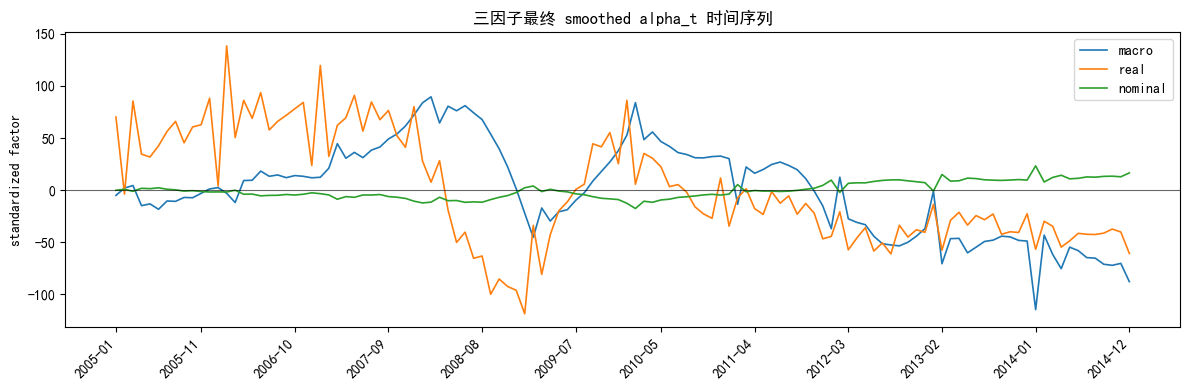

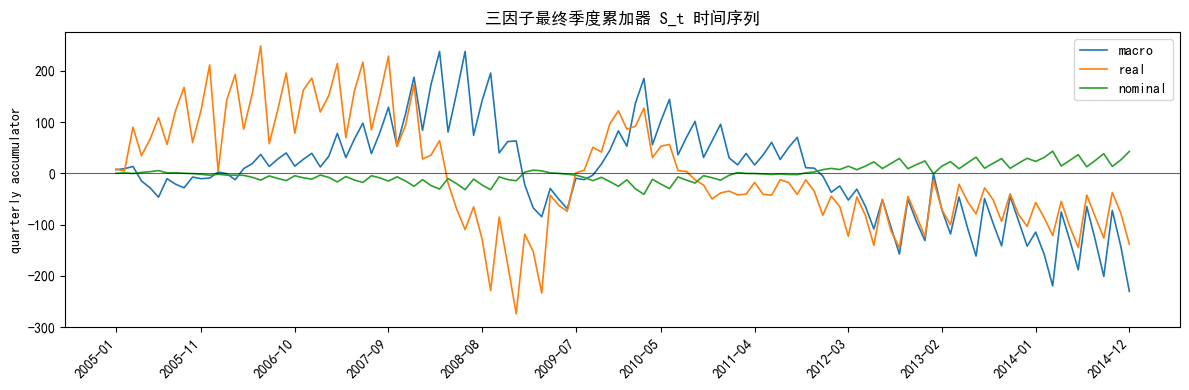

最终 smoothed alpha_t 年度均值：


,macro,real,nominal
year,,,
2005,-6.912414,53.295601,0.092579
2006,8.582890,68.537805,-3.541263
2007,41.005554,69.409923,-6.271918
2008,61.168979,-45.713202,-9.100173
2009,-6.241378,-11.232060,-3.058468
2010,43.865609,11.027981,-8.606400
2011,13.683938,-17.186136,0.165144
2012,-37.453495,-44.360591,7.427103
2013,-46.931055,-31.394906,9.359639


In [230]:
profiling_records = [row for row in globals().get('profiling_records', []) if row.get('phase') != 'EM']
em_start_time = time.perf_counter()
res=run_em(z.loc[TRAIN_START:TRAIN_END,model_cols_valid],ar,L,h)
em_runtime_seconds = time.perf_counter() - em_start_time
profiling_records.append({'phase': 'EM', 'runtime_seconds': em_runtime_seconds})
print(f'EM runtime: {em_runtime_seconds:.2f} seconds ({em_runtime_seconds / 60:.2f} minutes)')
st=res['smoother']['state']; hist=res['history']
paths={
 'ar':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_ar_params.csv','loading':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_loading.csv','h':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_h.csv','state':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_smoothed_state.csv','history':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_history.csv','meta':ESTIMATION_RESULT_DIR/f'{RESULT_PREFIX}_meta.json'}
res['ar'].to_csv(paths['ar'],encoding='utf-8-sig'); res['loading'].to_csv(paths['loading'],encoding='utf-8-sig'); res['h'].rename('h').to_csv(paths['h'],encoding='utf-8-sig'); st.to_csv(paths['state'],encoding='utf-8-sig'); hist.to_csv(paths['history'],encoding='utf-8-sig',index=False)
meta_out={'model':'three_factor_block_loading','train_start':str(TRAIN_START),'train_end':str(TRAIN_END),'factor_ar_order':FACTOR_AR_ORDER,'factors':FACTOR_NAMES,'real_activity_cols':REAL_COLS,'nominal_cols':NOMINAL_COLS,'macro_cols':MACRO_COLS,'allowed_factor_by_variable':allowed,'final_loglike':float(res['filter']['loglike']),'iterations':int(hist['iteration'].max()) if not hist.empty else 0,'a1':res['a1'].to_dict(),'implementation':'fast_numpy_loop','history_has_timing':True,'em_runtime_seconds':float(em_runtime_seconds),'max_iter':None,'relative_loglike_tol':float(TOL),'paper_relative_loglike_tol':float(RELATIVE_LOGLIKE_TOL),'em_to_qn_relative_loglike_tol':float(EM_TO_QN_REL_LOGLIKE_TOL)}
with open(paths['meta'],'w',encoding='utf-8') as f: json.dump(meta_out,f,ensure_ascii=False,indent=2)
for p in paths.values(): print(p)

print('最终 loading：')
display(res['loading'])
print('最终观测误差方差 H：')
display(res['h'].to_frame())
print('最近 EM history：')
display(hist.tail())
if {'filter_seconds','smoother_seconds','m_step_seconds','iteration_seconds'}.issubset(hist.columns):
    timing_summary=hist[['filter_seconds','smoother_seconds','m_step_seconds','iteration_seconds']].agg(['mean','max','sum']).T
    timing_summary['share_of_iteration_sum']=timing_summary['sum']/timing_summary.loc['iteration_seconds','sum']
    print('EM timing breakdown:')
    display(timing_summary)

factor_cols=[f'{f}_alpha_t' for f in FACTOR_NAMES]
factor_path=st[factor_cols].copy(); factor_path.columns=FACTOR_NAMES
factor_summary=factor_path.agg(['mean','std','min','max']).T
factor_summary.insert(0,'start',str(factor_path.index.min()))
factor_summary.insert(1,'end',str(factor_path.index.max()))
print('最终 smoothed alpha_t 因子摘要：')
display(factor_summary)

fig,ax=plt.subplots(figsize=(12,4))
plot_factor=factor_path.copy(); plot_factor.index=plot_factor.index.astype(str)
plot_factor.plot(ax=ax,linewidth=1.2)
ax.axhline(0,color='black',linewidth=0.8,alpha=0.6)
tick_positions=np.linspace(0,len(plot_factor.index)-1,min(12,len(plot_factor.index)),dtype=int)
ax.set_xticks(tick_positions); ax.set_xticklabels([plot_factor.index[i] for i in tick_positions],rotation=45,ha='right')
ax.set_title('三因子最终 smoothed alpha_t 时间序列')
ax.set_ylabel('standardized factor')
fig.tight_layout(); plt.show()

s_cols=[s_name(f) for f in FACTOR_NAMES]
s_path=st[s_cols].copy(); s_path.columns=FACTOR_NAMES
fig,ax=plt.subplots(figsize=(12,4))
plot_s=s_path.copy(); plot_s.index=plot_s.index.astype(str)
plot_s.plot(ax=ax,linewidth=1.2)
ax.axhline(0,color='black',linewidth=0.8,alpha=0.6)
tick_positions=np.linspace(0,len(plot_s.index)-1,min(12,len(plot_s.index)),dtype=int)
ax.set_xticks(tick_positions); ax.set_xticklabels([plot_s.index[i] for i in tick_positions],rotation=45,ha='right')
ax.set_title('三因子最终季度累加器 S_t 时间序列')
ax.set_ylabel('quarterly accumulator')
fig.tight_layout(); plt.show()

factor_by_year=factor_path.copy(); factor_by_year['year']=factor_by_year.index.year
factor_by_year=factor_by_year.groupby('year')[FACTOR_NAMES].mean()
print('最终 smoothed alpha_t 年度均值：')
display(factor_by_year)



em_results = {'ar_params': res['ar'], 'loading': res['loading'], 'h': res['h'], 'history': hist, 'filter_results': res['filter'], 'smoother_results': {'smoothed_state': st, 'smoothed_cov': res['smoother']['cov']}, 'a1': res['a1']}


### 14.5 Quasi-Newton refinement

This section keeps the same position and workflow as the single-factor QN notebook: EM first, then L-BFGS-B refinement on the same Kalman log likelihood.

The three-factor version changes only the parameter structure: three AR(15) blocks, block-loading-constrained loadings, diagonal H, and the initial state vector.


In [237]:
RUN_QUASI_NEWTON = globals().get("RUN_QUASI_NEWTON", True)


def relative_loglike_change(loglike: float, previous_loglike: float | None) -> float:
    if previous_loglike is None or not np.isfinite(previous_loglike):
        return np.nan
    denom = max(1.0, abs(float(previous_loglike)))
    return abs(float(loglike) - float(previous_loglike)) / denom


def aitken_loglike_gap(loglikes: list[float]) -> tuple[float, float]:
    if len(loglikes) < 3:
        return np.nan, np.nan
    l0, l1, l2 = [float(x) for x in loglikes[-3:]]
    denom = l0 - 2.0 * l1 + l2
    if not np.isfinite(denom) or abs(denom) < 1e-12:
        return np.nan, np.nan
    limit = l2 - ((l2 - l1) ** 2) / denom
    if not np.isfinite(limit):
        return np.nan, np.nan
    gap = abs(limit - l2) / max(1.0, abs(l2))
    return float(limit), float(gap)


QN_FTOL = globals().get("QN_FTOL", 1e-6)
QN_STOP_REL_CHANGE = globals().get("QN_STOP_REL_CHANGE", 1e-6)
QN_STOP_PATIENCE = globals().get("QN_STOP_PATIENCE", 5)
QN_AITKEN_RELATIVE_GAP_TOL = globals().get("QN_AITKEN_RELATIVE_GAP_TOL", 1e-4)


class QNEarlyStop(Exception):
    pass


QN_AR_COLUMNS = [f"rho_{i}" for i in range(1, FACTOR_AR_ORDER + 1)]
QN_OPTIMIZED_PARAMETERS = "AR only; loading, H, and initial state are fixed at EM estimates"


def _pack_qn_params(ar_params: pd.DataFrame) -> np.ndarray:
    return ar_params.loc[FACTOR_NAMES, QN_AR_COLUMNS].to_numpy(dtype=float).ravel()


def _unpack_qn_params(
    theta: np.ndarray,
    fixed_loading: pd.DataFrame,
    fixed_h: pd.Series,
    fixed_a1: pd.Series,
):
    theta = np.asarray(theta, dtype=float)
    n_ar = len(FACTOR_NAMES) * FACTOR_AR_ORDER
    ar_values = theta[:n_ar].reshape(len(FACTOR_NAMES), FACTOR_AR_ORDER)
    ar_params = pd.DataFrame(ar_values, index=FACTOR_NAMES, columns=QN_AR_COLUMNS)
    loading = fixed_loading.copy()
    h = fixed_h.clip(lower=MIN_H).copy()
    a1 = fixed_a1.copy()
    return ar_params, loading, h, a1

def run_quasi_newton_refinement(
    em_results: dict,
    y_panel: pd.DataFrame,
    start: pd.Period,
    end: pd.Period,
    max_iter: int | None = None,
):
    """Refine three-factor EM parameters by maximizing the Kalman log likelihood with L-BFGS-B."""
    if not RUN_QUASI_NEWTON:
        print("Quasi-Newton skipped because RUN_QUASI_NEWTON=False.")
        return em_results
    try:
        from scipy.optimize import minimize
    except Exception as exc:
        print(f"Quasi-Newton skipped: scipy.optimize is unavailable ({exc}).")
        return em_results

    y_train = y_panel.loc[start:end, model_cols_valid].copy()
    panel_cache = _build_fast_panel_cache(y_train)
    fixed_loading = em_results["loading"].copy()
    fixed_h = em_results["h"].clip(lower=MIN_H).copy()
    fixed_a1 = em_results.get("a1", pd.Series(0.0, index=STATE_NAMES)).loc[STATE_NAMES].copy()
    theta0 = _pack_qn_params(em_results["ar_params"])
    start_loglike = float(em_results["filter_results"]["loglike"])
    eval_count = 0
    best_loglike = start_loglike
    best_theta = theta0.copy()
    qn_trace = []
    qn_loglikes = []
    qn_stop_reason = ""
    last_iter_loglike = start_loglike
    small_change_streak = 0
    early_stop = False
    early_stop_message = ""

    def objective(theta: np.ndarray) -> float:
        nonlocal eval_count, best_loglike, best_theta
        eval_count += 1
        ar_params, loading, h_diag, a1 = _unpack_qn_params(theta, fixed_loading, fixed_h, fixed_a1)
        try:
            filt = kfilter_fast(panel_cache, ar_params, loading, h_diag, a1=a1.to_numpy(dtype=float), P1=None)
            loglike = float(filt["loglike"])
            if not np.isfinite(loglike):
                return 1e12
            if loglike > best_loglike:
                best_loglike = loglike
                best_theta = theta.copy()
            if eval_count == 1 or eval_count % 20 == 0:
                print(
                    f"QN eval {eval_count}: loglike={loglike:.6f}, "
                    f"best={best_loglike:.6f}, improvement={best_loglike - start_loglike:.6f}, "
                    f"min_h={float(h_diag.min()):.3g}"
                )
            return -loglike
        except Exception as exc:
            if eval_count == 1 or eval_count % 20 == 0:
                print(f"QN eval {eval_count}: failed objective evaluation: {exc}")
            return 1e12

    qn_iter = 0

    def callback(theta: np.ndarray):
        nonlocal qn_iter, last_iter_loglike, small_change_streak, early_stop, early_stop_message, qn_stop_reason
        qn_iter += 1
        ar_params, loading, h_diag, a1 = _unpack_qn_params(theta, fixed_loading, fixed_h, fixed_a1)
        filt = kfilter_fast(panel_cache, ar_params, loading, h_diag, a1=a1.to_numpy(dtype=float), P1=None)
        loglike = float(filt["loglike"])
        rel_loglike_change = relative_loglike_change(loglike, last_iter_loglike)
        qn_loglikes.append(loglike)
        aitken_loglike_limit, aitken_relative_gap = aitken_loglike_gap(qn_loglikes)
        if np.isfinite(rel_loglike_change) and rel_loglike_change < QN_STOP_REL_CHANGE:
            small_change_streak += 1
        else:
            small_change_streak = 0
        radius = max(
            ar_spectral_radius_values(ar_params.loc[factor, QN_AR_COLUMNS].to_numpy(dtype=float))
            for factor in FACTOR_NAMES
        )
        row = {
            "qn_iter": qn_iter,
            "eval_count": eval_count,
            "loglike": loglike,
            "best_loglike": best_loglike,
            "improvement": loglike - start_loglike,
            "best_improvement": best_loglike - start_loglike,
            "relative_loglike_change": rel_loglike_change,
            "aitken_loglike_limit": aitken_loglike_limit,
            "aitken_relative_gap": aitken_relative_gap,
            "small_change_streak": small_change_streak,
            "max_ar_spectral_radius": float(radius),
            "min_h": float(h_diag.min()),
            "max_h": float(h_diag.max()),
        }
        qn_trace.append(row)
        print(
            f"QN stop-check: rel_change={rel_loglike_change:.3e}, "
            f"aitken_gap={aitken_relative_gap:.3e}, "
            f"streak={small_change_streak}/{QN_STOP_PATIENCE}, "
            f"rel_threshold={QN_STOP_REL_CHANGE:g}, aitken_threshold={QN_AITKEN_RELATIVE_GAP_TOL:g}, "
            f"loglike={loglike:.6f}, best={best_loglike:.6f}, evals={eval_count}"
        )
        last_iter_loglike = loglike
        if small_change_streak >= QN_STOP_PATIENCE:
            qn_stop_reason = "relative_loglike_change"
            early_stop = True
            early_stop_message = (
                f"Stopped after {QN_STOP_PATIENCE} consecutive QN stop-checks with "
                f"relative_loglike_change < {QN_STOP_REL_CHANGE:g}."
            )
            raise QNEarlyStop(early_stop_message)
        if np.isfinite(aitken_relative_gap) and aitken_relative_gap < QN_AITKEN_RELATIVE_GAP_TOL:
            qn_stop_reason = "aitken_relative_gap"
            early_stop = True
            early_stop_message = (
                f"Stopped by QN Aitken gap {aitken_relative_gap:.3e} "
                f"< {QN_AITKEN_RELATIVE_GAP_TOL:g}."
            )
            raise QNEarlyStop(early_stop_message)

    bounds = [(None, None)] * len(theta0)

    options = {"ftol": QN_FTOL, "maxls": 20}
    if max_iter is not None:
        options["maxiter"] = int(max_iter)
    qn_max_fun = globals().get("QN_MAX_FUN", None)
    if qn_max_fun is not None:
        options["maxfun"] = int(qn_max_fun)

    print(
        f"Quasi-Newton start: method=L-BFGS-B, params={len(theta0)} ({QN_OPTIMIZED_PARAMETERS}), "
        f"max_iter={options.get('maxiter', 'unset')}, ftol={QN_FTOL:g}, "
        f"maxfun={options.get('maxfun', 'unset')}, "
        f"early_stop_rel_change={QN_STOP_REL_CHANGE:g}, patience={QN_STOP_PATIENCE}, "
        f"aitken_gap_tol={QN_AITKEN_RELATIVE_GAP_TOL:g}, start_loglike={start_loglike:.6f}"
    )
    opt = None
    try:
        opt = minimize(objective, theta0, method="L-BFGS-B", bounds=bounds, callback=callback, options=options)
    except QNEarlyStop as exc:
        print(str(exc))

    if opt is not None and not opt.success:
        print(f"QN optimizer stopped without success: {opt.message}")

    final_theta = best_theta
    ar_final, loading_final, h_final, a1_final = _unpack_qn_params(final_theta, fixed_loading, fixed_h, fixed_a1)
    final_filter = kfilter_fast(panel_cache, ar_final, loading_final, h_final, a1=a1_final.to_numpy(dtype=float), P1=None)
    final_smoother = smooth_fast(final_filter, return_frames=True)

    qn_result = {
        "success": bool(opt.success) if opt is not None else bool(early_stop),
        "message": str(opt.message) if opt is not None else early_stop_message,
        "early_stop": bool(early_stop),
        "stop_reason": qn_stop_reason,
        "qn_aitken_relative_gap_tol": float(QN_AITKEN_RELATIVE_GAP_TOL),
        "optimized_parameters": QN_OPTIMIZED_PARAMETERS,
        "start_loglike": float(start_loglike),
        "best_loglike": float(best_loglike),
        "improvement": float(best_loglike - start_loglike),
        "eval_count": int(eval_count),
        "qn_iterations": int(qn_iter),
    }

    refined = dict(em_results)
    refined.update({
        "ar_params": ar_final,
        "rho": ar_final,
        "loading": loading_final,
        "h": h_final,
        "H": build_H_from_diag(h_final),
        "a1": a1_final,
        "filter_results": final_filter,
        "smoother_results": {
            "smoothed_state": final_smoother["state"],
            "smoothed_cov": final_smoother["cov"],
        },
        "qn_result": qn_result,
        "qn_trace": pd.DataFrame(qn_trace),
    })
    return refined


if RUN_QUASI_NEWTON:
    profiling_records = [row for row in globals().get('profiling_records', []) if row.get('phase') != 'QN']
    qn_start_time = time.perf_counter()
    em_results = run_quasi_newton_refinement(
        em_results=em_results,
        y_panel=z,
        start=TRAIN_START,
        end=TRAIN_END,
        max_iter=globals().get("QN_MAX_ITER", None),
    )
    qn_runtime_seconds = time.perf_counter() - qn_start_time
    profiling_records.append({'phase': 'QN', 'runtime_seconds': qn_runtime_seconds})
    em_results.setdefault('qn_result', {})['qn_runtime_seconds'] = float(qn_runtime_seconds)
    print(f'QN runtime: {qn_runtime_seconds:.2f} seconds ({qn_runtime_seconds / 60:.2f} minutes)')
    res = {
        "ar": em_results["ar_params"],
        "loading": em_results["loading"],
        "h": em_results["h"],
        "a1": em_results["a1"],
        "history": em_results["history"],
        "filter": em_results["filter_results"],
        "smoother": {
            "state": em_results["smoother_results"]["smoothed_state"],
            "cov": em_results["smoother_results"]["smoothed_cov"],
        },
        "qn_trace": em_results.get("qn_trace", pd.DataFrame()),
        "qn_result": em_results.get("qn_result", {}),
    }
    st = em_results["smoother_results"]["smoothed_state"]

    qn_paths = {
        "ar": ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_qn_ar_params.csv",
        "loading": ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_qn_loading.csv",
        "h": ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_qn_h.csv",
        "state": ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_qn_smoothed_state.csv",
        "trace": ESTIMATION_RESULT_DIR / f"{RESULT_PREFIX}_qn_trace.csv",
    }
    em_results["ar_params"].to_csv(qn_paths["ar"], encoding="utf-8-sig")
    em_results["loading"].to_csv(qn_paths["loading"], encoding="utf-8-sig")
    em_results["h"].rename("h").to_csv(qn_paths["h"], encoding="utf-8-sig")
    st.to_csv(qn_paths["state"], encoding="utf-8-sig")
    em_results.get("qn_trace", pd.DataFrame()).to_csv(qn_paths["trace"], encoding="utf-8-sig", index=False)
    for path in qn_paths.values():
        print(path)


Quasi-Newton start: method=L-BFGS-B, params=45 (AR only; loading, H, and initial state are fixed at EM estimates), max_iter=unset, ftol=1e-05, maxfun=unset, early_stop_rel_change=1e-05, patience=5, aitken_gap_tol=0.0001, start_loglike=70.126484
QN eval 1: loglike=70.126484, best=70.126484, improvement=0.000000, min_h=0.000138
QN eval 20: loglike=70.126484, best=70.126485, improvement=0.000000, min_h=0.000138
QN eval 40: loglike=70.126484, best=70.126485, improvement=0.000000, min_h=0.000138
QN eval 60: loglike=-1131.841219, best=70.126485, improvement=0.000000, min_h=0.000138
QN eval 80: loglike=-1131.841227, best=70.126485, improvement=0.000000, min_h=0.000138
QN eval 100: loglike=56.573649, best=70.126485, improvement=0.000000, min_h=0.000138
QN eval 120: loglike=56.573646, best=70.126485, improvement=0.000000, min_h=0.000138
QN eval 140: loglike=70.204594, best=70.204594, improvement=0.078110, min_h=0.000138
QN eval 160: loglike=70.204593, best=70.204595, improvement=0.078111, min_h

### 14.6 QN diagnostic checks

This section checks post-QN H boundaries, loading magnitude, AR stability, and the recent QN trace.


In [232]:
h_check = em_results["h"].sort_values().to_frame("h_final")
h_check["near_lower_bound"] = h_check["h_final"] < MIN_H * 10
print("H boundary check.")
display(h_check)

loading_check = em_results["loading"].abs().stack().rename("abs_loading").sort_values(ascending=False).to_frame()
print("Loading magnitude check.")
display(loading_check.head(30))

ar_radius_check = pd.Series(
    {
        factor: ar_spectral_radius_values(em_results["ar_params"].loc[factor, QN_AR_COLUMNS].to_numpy(dtype=float))
        for factor in FACTOR_NAMES
    },
    name="spectral_radius",
)
print("AR spectral radius check.")
display(ar_radius_check.to_frame())

if "qn_trace" in em_results and not em_results["qn_trace"].empty:
    qn_trace_cols = [
        "qn_iter",
        "eval_count",
        "loglike",
        "best_loglike",
        "improvement",
        "relative_loglike_change",
        "max_ar_spectral_radius",
        "min_h",
        "max_h",
    ]
    qn_trace_cols = [col for col in qn_trace_cols if col in em_results["qn_trace"].columns]
    print("Recent QN trace.")
    display(em_results["qn_trace"][qn_trace_cols].tail(20))
else:
    print("No QN trace is available. Run the QN cell first if diagnostics are needed.")


H boundary check.


,h_final,near_lower_bound
CPI,0.000138,True
GDP同比,0.061444,False
社零,0.092626,False
服务业PMI,0.123547,False
工业增加值,0.266905,False
PPI,0.365278,False
制造业PMI_去季节性,0.472646,False
固投累计同比_去季节性,0.545476,False
用电量,0.584870,False


Loading magnitude check.


abs_loading
CPI         nominal     0.374227
PPI         nominal     0.169080
CPI         macro       0.077542
服务业PMI      real        0.060628
            macro       0.046726
PPI         macro       0.045446
社零          macro       0.023443
制造业PMI_去季节性 real        0.012615
工业增加值       real        0.012259
固投累计同比_去季节性 macro       0.011371
社零          real        0.010721
用电量         macro       0.009833
工业增加值       macro       0.008111
用电量         real        0.006168
固投累计同比_去季节性 real        0.006089
GDP同比       real        0.005174
            macro       0.002742
制造业PMI_去季节性 macro       0.002725
GDP同比       nominal     0.000000
工业增加值       nominal     0.000000
服务业PMI      nominal     0.000000
用电量         nominal     0.000000
社零          nominal     0.000000
CPI         real        0.000000
PPI         real        0.000000
制造业PMI_去季节性 nominal     0.000000
固投累计同比_去季节性 nominal     0.000000

AR spectral radius check.


,spectral_radius
macro,1.022121
real,0.997935
nominal,1.020271


Recent QN trace.


,qn_iter,eval_count,loglike,best_loglike,improvement,relative_loglike_change,max_ar_spectral_radius,min_h,max_h
0,1,184,70.094388,70.094388,0.007016,0.000100,1.022121,0.000138,0.58487
1,2,230,70.117976,70.117977,0.030605,0.000337,1.022121,0.000138,0.58487
2,3,276,70.126484,70.126484,0.039112,0.000121,1.022121,0.000138,0.58487


## 15. 使用 EM 参数生成训练窗口后一年的 GDP 预测

本节使用当前训练窗口估计得到的 EM 参数，对训练窗口之后最多 12 个月做滚动外推检查。

关键设定：

- 预测起点自动设为 `TRAIN_END + 1`。
- 预测期月度变量使用训练期缩尾阈值处理，再用训练期均值和标准差标准化。
- 预测期 GDP 观测设为缺失，只用于事后对比。
- 后续扩窗时只需要修改 `TRAIN_START` / `TRAIN_END`，本节会自动移动到新训练窗口后一年的预测期。


训练窗口后一年的 GDP 季度末预测：


,value
forecast_start,2015-01
forecast_end,2015-12
n_quarters,4
n_actual_available,4
mean_error_raw,0.448073
mae_raw,0.448073
rmse_raw,0.512928
corr_raw,0.250263


,month,is_quarter_end,gdp_forecast_std,gdp_forecast_raw,actual_gdp_raw,actual_gdp_std,macro_alpha_t_forecast,real_alpha_t_forecast,nominal_alpha_t_forecast,macro_S_t_forecast,real_S_t_forecast,nominal_S_t_forecast,forecast_error_raw,abs_error_raw,squared_error_raw
2,2015-03,True,-0.989746,7.779414,7.1,NaN,-55.235627,-55.041903,9.534762,-107.627142,-134.257451,17.818418,0.679414,0.679414,0.461603
5,2015-06,True,-1.122060,7.474533,7.1,NaN,-59.202452,-59.215845,9.072069,-140.327506,-142.501493,22.099692,0.374533,0.374533,0.140275
8,2015-09,True,-1.297230,7.070905,7.0,NaN,-52.092698,-47.543608,7.036932,-164.437420,-163.580637,22.627842,0.070905,0.070905,0.005028
11,2015-12,True,-1.081741,7.567438,6.9,NaN,-1.672291,-44.767881,-3.909169,-103.280395,-154.341163,8.891111,0.667438,0.667438,0.445474


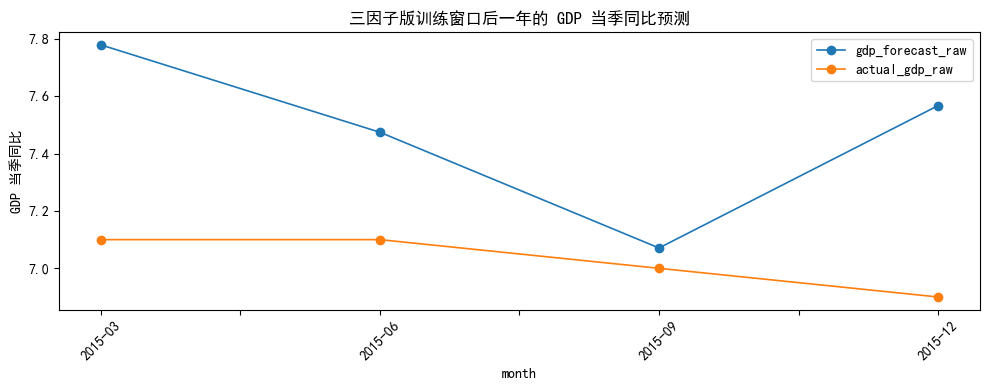

C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_post_train_1y_gdp_forecast.csv
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_post_train_1y_gdp_forecast.png


In [233]:
FORECAST_START = TRAIN_END + 1
FORECAST_END = TRAIN_END + 12
forecast_months = pd.period_range(FORECAST_START, FORECAST_END, freq='M')

state_prev = st.loc[TRAIN_END, STATE_NAMES].to_numpy(float).copy()
ar_forecast = res['ar']
gdp_loading = res['loading'].loc[GDP_COL, FACTOR_NAMES]
forecast_rows = []
for m in forecast_months:
    T_raw = trans(m, ar_forecast)
    T = T_raw.to_numpy(float) if hasattr(T_raw, 'to_numpy') else np.asarray(T_raw, dtype=float)
    state_prev = T @ state_prev
    state_s = pd.Series(state_prev, index=STATE_NAMES, name=m)
    gdp_fitted_std = float(sum(float(gdp_loading[f]) * state_s[s_name(f)] for f in FACTOR_NAMES)) if q_end(m) else np.nan
    gdp_fitted_raw = np.nan
    if np.isfinite(gdp_fitted_std):
        gdp_fitted_raw = gdp_fitted_std * float(params.loc[GDP_COL,'std_train']) + float(params.loc[GDP_COL,'mean_train'])
    actual_raw = float(raw.loc[m, GDP_COL]) if m in raw.index and pd.notna(raw.loc[m, GDP_COL]) else np.nan
    actual_std = float(z.loc[m, GDP_COL]) if m in z.index and pd.notna(z.loc[m, GDP_COL]) else np.nan
    forecast_rows.append({
        TIME_COL: str(m),
        'is_quarter_end': q_end(m),
        'gdp_forecast_std': gdp_fitted_std,
        'gdp_forecast_raw': gdp_fitted_raw,
        'actual_gdp_raw': actual_raw,
        'actual_gdp_std': actual_std,
        **{f'{f}_alpha_t_forecast': float(state_s[f'{f}_alpha_t']) for f in FACTOR_NAMES},
        **{f'{f}_S_t_forecast': float(state_s[s_name(f)]) for f in FACTOR_NAMES},
    })

forecast_df = pd.DataFrame(forecast_rows)
forecast_q = forecast_df.loc[forecast_df['is_quarter_end']].copy()
forecast_q['forecast_error_raw'] = forecast_q['gdp_forecast_raw'] - forecast_q['actual_gdp_raw']
forecast_q['abs_error_raw'] = forecast_q['forecast_error_raw'].abs()
forecast_q['squared_error_raw'] = forecast_q['forecast_error_raw'] ** 2
forecast_path = ESTIMATION_RESULT_DIR / f'{RESULT_PREFIX}_post_train_1y_gdp_forecast.csv'
forecast_q.to_csv(forecast_path, encoding='utf-8-sig', index=False)

forecast_metrics = pd.Series({
    'forecast_start': str(FORECAST_START),
    'forecast_end': str(FORECAST_END),
    'n_quarters': int(len(forecast_q)),
    'n_actual_available': int(forecast_q['actual_gdp_raw'].notna().sum()),
    'mean_error_raw': forecast_q['forecast_error_raw'].mean(skipna=True),
    'mae_raw': forecast_q['abs_error_raw'].mean(skipna=True),
    'rmse_raw': float(np.sqrt(forecast_q['squared_error_raw'].mean(skipna=True))) if forecast_q['squared_error_raw'].notna().any() else np.nan,
    'corr_raw': forecast_q[['gdp_forecast_raw','actual_gdp_raw']].corr().iloc[0,1] if forecast_q['actual_gdp_raw'].notna().sum() >= 2 else np.nan,
})
print('训练窗口后一年的 GDP 季度末预测：')
display(forecast_metrics.to_frame('value'))
display(forecast_q)

fig, ax = plt.subplots(figsize=(10,4))
plot_cols = ['gdp_forecast_raw'] + (['actual_gdp_raw'] if forecast_q['actual_gdp_raw'].notna().any() else [])
plot_forecast = forecast_q.set_index(TIME_COL)[plot_cols].copy()
plot_forecast.plot(ax=ax, marker='o', linewidth=1.2)
ax.set_title('三因子版训练窗口后一年的 GDP 当季同比预测')
ax.set_ylabel('GDP 当季同比')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
forecast_png = ESTIMATION_RESULT_DIR / f'{RESULT_PREFIX}_post_train_1y_gdp_forecast.png'
fig.savefig(forecast_png, dpi=180)
plt.show()
print(forecast_path)
print(forecast_png)



## 16. 三因子经济状态展示

本节使用最终 EM 参数下的 Kalman smoother 结果，分别展示训练窗口内三个共同因子的月度状态：

$$
\widehat{\alpha}^{macro}_t,\quad
\widehat{\alpha}^{real}_t,\quad
\widehat{\alpha}^{nominal}_t
$$

以及 GDP 观测方程实际使用的三个 Harvey 季度累加器：

$$
S^{macro}_t,\quad S^{real}_t,\quad S^{nominal}_t
$$

其中 $\widehat{\alpha}_t$ 反映月度共同状态，$S_t$ 是季度末 GDP 拟合中进入观测方程的状态。


三因子 smoothed alpha_t 摘要：


,start,end,mean,std,min,max
macro,2005-01,2014-12,0.079184,43.862847,-114.737074,89.493808
real,2005-01,2014-12,0.814235,53.104078,-118.638064,138.382714
nominal,2005-01,2014-12,-0.016408,7.966401,-17.658886,23.245641


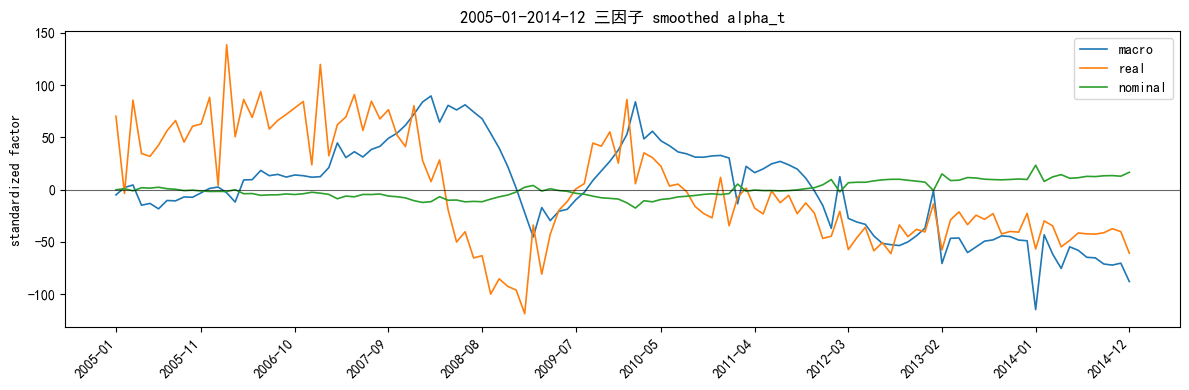

三因子 Harvey 季度累加器 S_t 摘要：


,start,end,mean,std,min,max
macro,2005-01,2014-12,0.497428,92.848184,-230.471190,237.629464
real,2005-01,2014-12,0.328805,107.551873,-273.839610,248.736490
nominal,2005-01,2014-12,-0.038095,16.764850,-40.971887,43.152838


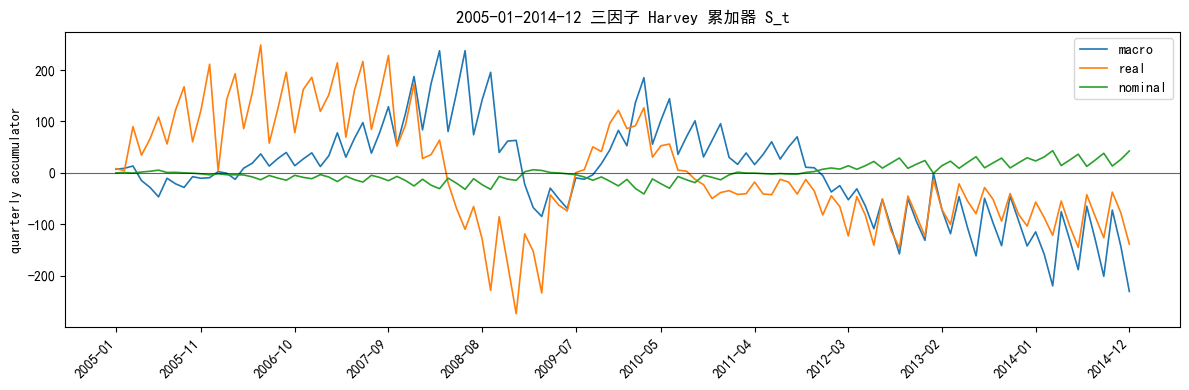

三因子 smoothed alpha_t 年度均值：


,macro,real,nominal
year,,,
2005,-6.920061,53.275391,0.094163
2006,8.592575,68.603602,-3.543270
2007,41.003135,69.362380,-6.271417
2008,61.172921,-45.681581,-9.100990
2009,-6.241814,-11.244120,-3.058378
2010,43.857606,11.000284,-8.604741
2011,13.694459,-17.143606,0.162964
2012,-37.467039,-44.376158,7.429910
2013,-46.946547,-31.411302,9.362848


In [234]:
final_smoothed_state = st.copy()

factor_cols = [f'{f}_alpha_t' for f in FACTOR_NAMES]
economic_state_factor = final_smoothed_state[factor_cols].copy()
economic_state_factor.columns = FACTOR_NAMES
factor_summary = economic_state_factor.agg(['mean','std','min','max']).T
factor_summary.insert(0, 'start', str(economic_state_factor.index.min()))
factor_summary.insert(1, 'end', str(economic_state_factor.index.max()))
print('三因子 smoothed alpha_t 摘要：')
display(factor_summary)

fig, ax = plt.subplots(figsize=(12, 4))
plot_df = economic_state_factor.copy()
plot_df.index = plot_df.index.astype(str)
plot_df.plot(ax=ax, linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
tick_positions = np.linspace(0, len(plot_df.index) - 1, min(12, len(plot_df.index)), dtype=int)
ax.set_xticks(tick_positions)
ax.set_xticklabels([plot_df.index[i] for i in tick_positions], rotation=45, ha='right')
ax.set_title(f'{TRAIN_START}-{TRAIN_END} 三因子 smoothed alpha_t')
ax.set_ylabel('standardized factor')
plt.tight_layout()
plt.show()

s_cols = [s_name(f) for f in FACTOR_NAMES]
economic_state_accumulator = final_smoothed_state[s_cols].copy()
economic_state_accumulator.columns = FACTOR_NAMES
s_summary = economic_state_accumulator.agg(['mean','std','min','max']).T
s_summary.insert(0, 'start', str(economic_state_accumulator.index.min()))
s_summary.insert(1, 'end', str(economic_state_accumulator.index.max()))
print('三因子 Harvey 季度累加器 S_t 摘要：')
display(s_summary)

fig, ax = plt.subplots(figsize=(12, 4))
plot_s = economic_state_accumulator.copy()
plot_s.index = plot_s.index.astype(str)
plot_s.plot(ax=ax, linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
tick_positions = np.linspace(0, len(plot_s.index) - 1, min(12, len(plot_s.index)), dtype=int)
ax.set_xticks(tick_positions)
ax.set_xticklabels([plot_s.index[i] for i in tick_positions], rotation=45, ha='right')
ax.set_title(f'{TRAIN_START}-{TRAIN_END} 三因子 Harvey 累加器 S_t')
ax.set_ylabel('quarterly accumulator')
plt.tight_layout()
plt.show()

factor_by_year = economic_state_factor.assign(year=economic_state_factor.index.year).groupby('year')[FACTOR_NAMES].mean()
print('三因子 smoothed alpha_t 年度均值：')
display(factor_by_year)


## 17. Training-period GDP backtest

This section reports two training-period views:

1. `smoothed fit`: in-sample explanatory fit using the final smoothed state. This is not a real-time nowcast.
2. `filtered nowcast`: for each month, use only the filtered state available through that month, project it to that month's quarter end, and compare the monthly nowcast with the realized quarter-end GDP.

The GDP measurement equation is:

$$
GDP_t^{std}
= \lambda_{GDP,macro} S^{macro}_t
+ \lambda_{GDP,real} S^{real}_t
+ \lambda_{GDP,nominal} S^{nominal}_t
+ \varepsilon_{GDP,t}
$$

Both the quarter-end smoothed fit and monthly filtered nowcast use the same linear combination of the three quarterly accumulators, then convert the result back to raw GDP YoY units.


Training-period GDP smoothed fit:


,value
n_quarters,40.000000
mean_error_raw,0.014112
mae_raw,0.398614
rmse_raw,0.522349
corr_raw,0.974035


,gdp_fitted_std,gdp_fitted_raw,actual_gdp_raw,actual_gdp_std,is_quarter_end,fitted_error_raw,abs_error_raw,squared_error_raw
2005-03,0.502182,11.217136,11.2,0.494746,True,0.017136,0.017136,0.000294
2005-06,0.434086,11.060228,11.1,0.451347,True,-0.039772,0.039772,0.001582
2005-09,0.789343,11.878815,10.9,0.364550,True,0.978815,0.978815,0.958078
2005-12,1.067837,12.520525,12.4,1.015531,True,0.120525,0.120525,0.014526
2006-03,0.963249,12.279531,12.4,1.015531,True,-0.120469,0.120469,0.014513


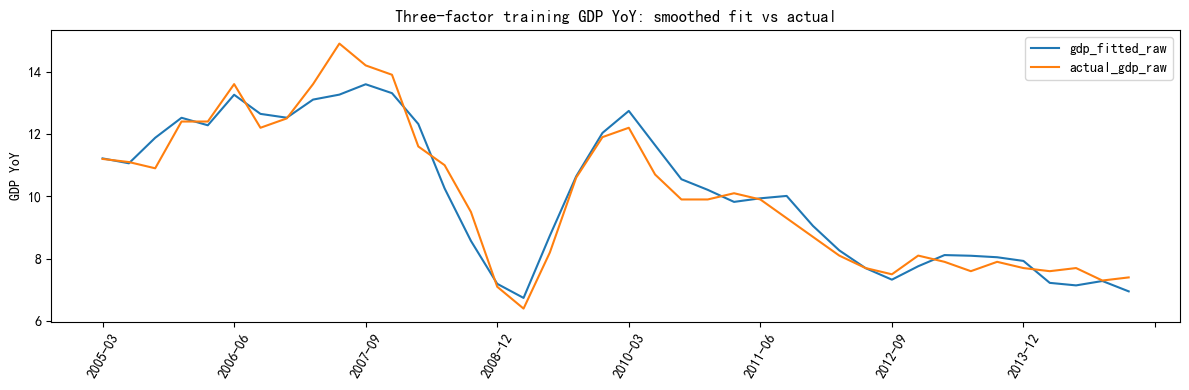

Training-period GDP filtered monthly nowcast:


,n_months,mean_error_raw,mae_raw,rmse_raw
months_before_quarter_end,,,,
2,40,0.162764,0.692056,0.920343
1,40,0.118147,0.607819,0.786746
0,40,0.043311,0.337526,0.437203


,month,target_quarter_end,months_before_quarter_end,filtered_nowcast_std,filtered_nowcast_raw,actual_gdp_raw,actual_gdp_std,nowcast_error_raw,macro_S_target_nowcast,real_S_target_nowcast,nominal_S_target_nowcast,abs_error_raw,squared_error_raw
0,2005-01,2005-03,2,0.507659,11.229756,11.2,0.494746,0.029756,9.351834,93.161682,-0.085989,0.029756,0.000885
1,2005-02,2005-03,1,0.410093,11.004943,11.2,0.494746,-0.195057,2.032752,78.183304,1.113097,0.195057,0.038047
2,2005-03,2005-03,0,0.391760,10.962698,11.2,0.494746,-0.237302,16.314346,67.071588,-0.962294,0.237302,0.056312
3,2005-04,2005-06,2,0.634171,11.521266,11.1,0.451347,0.421266,-38.015230,142.714450,3.888912,0.421266,0.177465
4,2005-05,2005-06,1,0.936598,12.218121,11.1,0.451347,1.118121,-25.262712,194.407799,1.518721,1.118121,1.250196
5,2005-06,2005-06,0,0.636715,11.527128,11.1,0.451347,0.427128,-31.748682,139.885322,2.257911,0.427128,0.182438
6,2005-07,2005-09,2,1.028843,12.430675,10.9,0.364550,1.530675,-6.498383,202.292680,-3.723070,1.530675,2.342965
7,2005-08,2005-09,1,0.906444,12.148640,10.9,0.364550,1.248640,-10.861353,180.948038,-3.398221,1.248640,1.559101
8,2005-09,2005-09,0,0.712077,11.700777,10.9,0.364550,0.800777,-31.881984,154.521418,0.835296,0.800777,0.641244
9,2005-10,2005-12,2,0.971123,12.297674,12.4,1.015531,-0.102326,-14.701332,195.483782,-4.141879,0.102326,0.010471


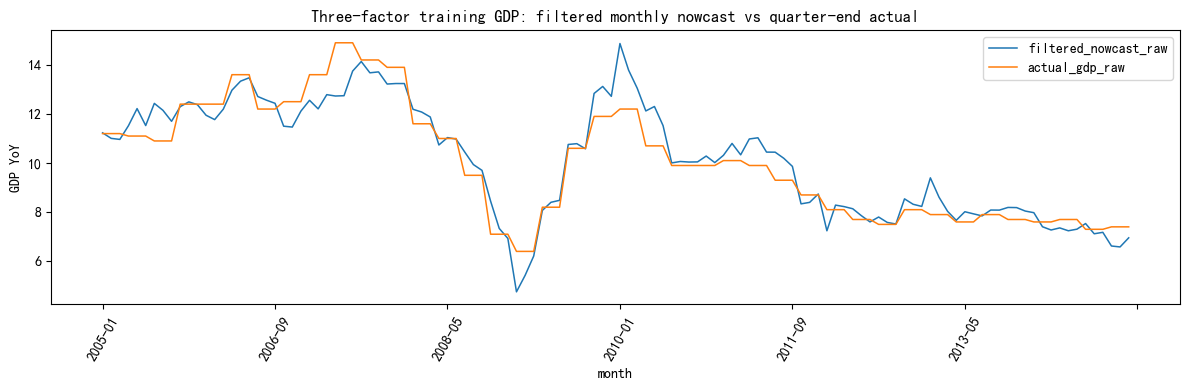

C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_train_gdp_backtest.csv
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_train_gdp_fit.png
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_train_gdp_filtered_monthly_nowcast.csv
C:\Users\戴璐\Desktop\实习\动态因子模型\月频模型\模型流程中产物\8-模型估计结果\threefactor_qn_em_qn_200501_201412_ar15_train_gdp_filtered_monthly_nowcast.png


In [235]:
gL = res['loading'].loc[GDP_COL, FACTOR_NAMES]

def gdp_from_state(state_s: pd.Series) -> float:
    return float(sum(float(gL[f]) * float(state_s[s_name(f)]) for f in FACTOR_NAMES))


def inverse_standardize_gdp(gdp_std_value: float) -> float:
    return gdp_std_value * float(params.loc[GDP_COL, 'std_train']) + float(params.loc[GDP_COL, 'mean_train'])


def quarter_end_month(m: pd.Period) -> pd.Period:
    q_end_month = ((m.month - 1) // 3 + 1) * 3
    return pd.Period(f'{m.year}-{q_end_month:02d}', freq='M')


def project_state_to_month(state_vec: np.ndarray, from_month: pd.Period, target_month: pd.Period, ar_params: pd.DataFrame) -> np.ndarray:
    out = np.asarray(state_vec, dtype=float).copy()
    cur = from_month
    while cur < target_month:
        nxt = cur + 1
        T_raw = trans(nxt, ar_params)
        T = T_raw.to_numpy(float) if hasattr(T_raw, 'to_numpy') else np.asarray(T_raw, dtype=float)
        out = T @ out
        cur = nxt
    return out

# Smoothed in-sample fit: only quarter-end months are directly comparable with observed GDP.
gfit_std = sum(gL[f] * st[s_name(f)] for f in FACTOR_NAMES)
gfit_raw = gfit_std * float(params.loc[GDP_COL, 'std_train']) + float(params.loc[GDP_COL, 'mean_train'])
bt = pd.DataFrame({
    'gdp_fitted_std': gfit_std,
    'gdp_fitted_raw': gfit_raw,
    'actual_gdp_raw': raw.loc[TRAIN_START:TRAIN_END, GDP_COL],
    'actual_gdp_std': z.loc[TRAIN_START:TRAIN_END, GDP_COL],
})
bt['is_quarter_end'] = [q_end(m) for m in bt.index]
bt = bt.loc[bt['is_quarter_end'] & bt['actual_gdp_raw'].notna()].copy()
bt['fitted_error_raw'] = bt['gdp_fitted_raw'] - bt['actual_gdp_raw']
bt['abs_error_raw'] = bt['fitted_error_raw'].abs()
bt['squared_error_raw'] = bt['fitted_error_raw'] ** 2

bt_path = ESTIMATION_RESULT_DIR / f'{RESULT_PREFIX}_train_gdp_backtest.csv'
bt.to_csv(bt_path, encoding='utf-8-sig')

metrics = pd.Series({
    'n_quarters': len(bt),
    'mean_error_raw': bt['fitted_error_raw'].mean(),
    'mae_raw': bt['abs_error_raw'].mean(),
    'rmse_raw': float(np.sqrt(bt['squared_error_raw'].mean())),
    'corr_raw': bt[['gdp_fitted_raw', 'actual_gdp_raw']].corr().iloc[0, 1],
})
print('Training-period GDP smoothed fit:')
display(metrics.to_frame('value'))
display(bt.head())

fig, ax = plt.subplots(figsize=(12, 4))
plot = bt[['gdp_fitted_raw', 'actual_gdp_raw']].copy()
plot.index = plot.index.astype(str)
plot.plot(ax=ax)
ax.set_title('Three-factor training GDP YoY: smoothed fit vs actual')
ax.set_ylabel('GDP YoY')
ax.tick_params(axis='x', rotation=60)
fig.tight_layout()
png = ESTIMATION_RESULT_DIR / f'{RESULT_PREFIX}_train_gdp_fit.png'
fig.savefig(png, dpi=180)
plt.show()

# Filtered monthly nowcast: each month nowcasts the GDP value at that month's quarter end.
fr = res['filter']
filtered_state = pd.DataFrame(fr['af'], index=fr['months'], columns=STATE_NAMES)
filtered_rows = []
for m, row in filtered_state.loc[TRAIN_START:TRAIN_END].iterrows():
    target_q_end = quarter_end_month(m)
    if target_q_end > TRAIN_END:
        continue
    projected_vec = project_state_to_month(row.to_numpy(float), m, target_q_end, res['ar'])
    projected_state = pd.Series(projected_vec, index=STATE_NAMES)
    nowcast_std = gdp_from_state(projected_state)
    nowcast_raw = inverse_standardize_gdp(nowcast_std)
    actual_raw = float(raw.loc[target_q_end, GDP_COL]) if target_q_end in raw.index and pd.notna(raw.loc[target_q_end, GDP_COL]) else np.nan
    actual_std = float(z.loc[target_q_end, GDP_COL]) if target_q_end in z.index and pd.notna(z.loc[target_q_end, GDP_COL]) else np.nan
    filtered_rows.append({
        TIME_COL: str(m),
        'target_quarter_end': str(target_q_end),
        'months_before_quarter_end': int(target_q_end.month - m.month),
        'filtered_nowcast_std': nowcast_std,
        'filtered_nowcast_raw': nowcast_raw,
        'actual_gdp_raw': actual_raw,
        'actual_gdp_std': actual_std,
        'nowcast_error_raw': nowcast_raw - actual_raw if np.isfinite(actual_raw) else np.nan,
        **{f'{f}_S_target_nowcast': float(projected_state[s_name(f)]) for f in FACTOR_NAMES},
    })

filtered_bt = pd.DataFrame(filtered_rows)
filtered_bt['abs_error_raw'] = filtered_bt['nowcast_error_raw'].abs()
filtered_bt['squared_error_raw'] = filtered_bt['nowcast_error_raw'] ** 2
filtered_path = ESTIMATION_RESULT_DIR / f'{RESULT_PREFIX}_train_gdp_filtered_monthly_nowcast.csv'
filtered_bt.to_csv(filtered_path, encoding='utf-8-sig', index=False)

filtered_metrics = filtered_bt.groupby('months_before_quarter_end').agg(
    n_months=('nowcast_error_raw', 'count'),
    mean_error_raw=('nowcast_error_raw', 'mean'),
    mae_raw=('abs_error_raw', 'mean'),
    rmse_raw=('squared_error_raw', lambda s: float(np.sqrt(s.mean()))),
).sort_index(ascending=False)

print('Training-period GDP filtered monthly nowcast:')
display(filtered_metrics)
display(filtered_bt.head(12))

fig, ax = plt.subplots(figsize=(12, 4))
plot_filtered = filtered_bt.set_index(TIME_COL)[['filtered_nowcast_raw', 'actual_gdp_raw']].copy()
plot_filtered.plot(ax=ax, linewidth=1.1)
ax.set_title('Three-factor training GDP: filtered monthly nowcast vs quarter-end actual')
ax.set_ylabel('GDP YoY')
ax.tick_params(axis='x', rotation=60)
fig.tight_layout()
filtered_png = ESTIMATION_RESULT_DIR / f'{RESULT_PREFIX}_train_gdp_filtered_monthly_nowcast.png'
fig.savefig(filtered_png, dpi=180)
plt.show()

print(bt_path)
print(png)
print(filtered_path)
print(filtered_png)


### Runtime profiling


In [236]:
profiling_records = globals().get('profiling_records', [])
profiling_df = pd.DataFrame(profiling_records)
if profiling_df.empty:
    profiling_df = pd.DataFrame([
        {'phase': 'EM', 'runtime_seconds': globals().get('em_runtime_seconds', np.nan)},
        {'phase': 'QN', 'runtime_seconds': globals().get('qn_runtime_seconds', np.nan)},
    ])
else:
    profiling_df = profiling_df.drop_duplicates(subset=['phase'], keep='last')

phase_order = ['EM', 'QN']
if 'QN' not in profiling_df['phase'].tolist():
    profiling_df = pd.concat([
        profiling_df,
        pd.DataFrame([{'phase': 'QN', 'runtime_seconds': globals().get('qn_runtime_seconds', np.nan)}]),
    ], ignore_index=True)
profiling_df['phase'] = pd.Categorical(profiling_df['phase'], categories=phase_order, ordered=True)
profiling_df = profiling_df.sort_values('phase').reset_index(drop=True)
profiling_df['runtime_minutes'] = profiling_df['runtime_seconds'] / 60
print('EM / QN runtime profiling:')
display(profiling_df)


EM / QN runtime profiling:


,phase,runtime_seconds,runtime_minutes
0,EM,64.166489,1.069441
1,QN,10.578068,0.176301
